## **Modelo competidor no Desafio de Previsão de Sucesso de Startups**

- Objetivo: Prever se uma startup terá sucesso ou não.

#### **Sumário**

1. Exploração de dados
2. Pré-Processamento
3. Codificação de variáveis categóricas
4. Análise Exploratória Avançada
5. Análise de Features Categóricas
6. Identificando Correlações com a Target
7. Preparação Final para Modelagem
8. Formulando Hipóteses
9. Seleção de Features
10. Construção e Avaliação do Modelo
11. Finetuning de Hiperparâmetros
12. Otimização Avançada do Gradient Boosting
13. Geração de Predição para submissão

#### **1. Exploração de dados**

&nbsp;&nbsp;&nbsp;&nbsp;Aqui é feita a exploração inicial dos dados, visando compreender os dados recebidos, é o primeiro passo para a correta manipulação e utilização dos dados

In [1]:
import pandas as pd 
import seaborn as sns

- Primeira visualização do dataframe de treino com raw data:

In [2]:
df_train = pd.read_csv("./train.csv")
df_train.head(40)

,id,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,labels
0,719,10.42,13.09,8.98,12.72,4,3,4087500,3,1,...,0,0,1,1,0,0,0,0,1.0000,0
1,429,3.79,3.79,NaN,NaN,21,1,45000000,0,0,...,0,0,0,0,0,1,0,0,1.0000,1
2,178,0.71,2.28,1.95,2.28,5,2,5200000,2,1,...,0,1,1,0,1,0,0,0,1.0000,0
3,197,3.00,5.00,9.62,10.39,16,2,14500000,2,0,...,0,0,0,1,0,1,0,0,2.0000,1
4,444,0.66,5.88,6.21,8.61,29,5,70000000,4,1,...,0,0,0,0,1,1,1,1,2.8000,1
5,67,1.09,1.09,NaN,NaN,5,1,20500000,0,0,...,0,0,1,0,0,0,0,0,4.0000,0
6,505,0.65,0.65,NaN,NaN,3,1,900000,0,1,...,0,0,0,0,1,0,0,0,1.0000,0
7,410,0.34,5.22,3.00,6.03,5,4,48730000,3,0,...,0,0,1,0,1,1,1,0,3.0000,1
8,284,0.00,0.00,0.74,0.74,2,1,50000,1,1,...,0,0,0,1,0,0,0,0,2.0000,0
9,252,0.08,4.33,3.66,5.61,12,7,88651133,5,0,...,0,0,1,1,1,1,1,1,3.1667,1


In [3]:
df_train.dtypes

id                            int64
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
is_CA                         int64
is_NY                         int64
is_MA                         int64
is_TX                         int64
is_otherstate                 int64
category_code                object
is_software                   int64
is_web                        int64
is_mobile                     int64
is_enterprise                 int64
is_advertising                int64
is_gamesvideo                 int64
is_ecommerce                  int64
is_biotech                    int64
is_consulting                 int64
is_othercategory              int64
has_VC                        int64
has_angel                     int64
has_roundA                  

- Observações:

>as colunas "age_first_funding_year", "age_last_funding_year", "age_first_milestone_year" e "age_last_milestone_year" tem dados faltantes.

- É necessário fazer um pré-processamento dos dados

- Primeira visualização do dataframe de teste com raw data:

In [4]:
df_test = pd.read_csv("./test.csv")
df_test.head(20)

,id,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,is_biotech,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants
0,70,1.33,3.02,3.02,3.34,9,3,11489687,2,1,...,0,0,0,0,1,1,1,0,0,3.3333
1,23,5.49,5.49,0.00,0.00,1,1,3170000,1,1,...,0,0,0,0,0,1,0,0,0,2.0000
2,389,5.84,8.22,NaN,NaN,4,3,47218498,0,1,...,0,0,1,1,0,0,0,1,1,3.3333
3,872,6.30,6.30,6.00,6.00,9,1,15000000,1,1,...,1,0,0,0,0,0,0,0,0,3.0000
4,920,7.25,9.23,6.00,6.00,1,3,52000000,1,0,...,0,0,1,1,0,0,1,0,0,2.6667
5,690,0.00,1.50,1.58,3.17,7,2,1400000,2,0,...,0,0,1,0,1,1,0,0,0,6.0000
6,588,0.15,0.15,NaN,NaN,4,1,600000,0,0,...,0,0,0,0,1,0,0,0,0,2.0000
7,144,1.92,1.92,2.00,2.00,4,1,4410000,1,1,...,0,0,0,0,0,1,0,0,0,1.0000
8,875,0.17,3.78,3.84,6.12,6,2,626096,3,0,...,0,0,0,1,0,1,0,0,0,1.0000
9,900,1.30,2.47,0.00,2.47,3,2,1800000,2,0,...,0,0,1,1,1,0,0,0,0,5.0000


- Observações:

>as colunas "age_first_funding_year", "age_last_funding_year", "age_first_milestone_year" e "age_last_milestone_year" tem dados faltantes.

- Assim como o df de treino, o de teste precisa de um pré-processamento dos dados.

**2. Pré-Processamento**

In [5]:
import numpy as np
import matplotlib.pyplot as plt 

- Para o tratamento dos valores núlos, verifiquei se haveria algum problema em substituir por 0. Vendo a tabela e comportamento dos demais dados, é possivel oberservar que é existem outras linhas zeradas naturalmente, então compreende-se que não é um problema substituir as colunas núlas por 0.

Preenchendo os valores núlos por 0 na tabela de treino:

In [6]:
#Preenchendo os valores núlos por 0 na tabela de treino.
df_train = df_train.fillna(0)
df_train.head()

,id,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,labels
0,719,10.42,13.09,8.98,12.72,4,3,4087500,3,1,...,0,0,1,1,0,0,0,0,1.0,0
1,429,3.79,3.79,0.00,0.00,21,1,45000000,0,0,...,0,0,0,0,0,1,0,0,1.0,1
2,178,0.71,2.28,1.95,2.28,5,2,5200000,2,1,...,0,1,1,0,1,0,0,0,1.0,0
3,197,3.00,5.00,9.62,10.39,16,2,14500000,2,0,...,0,0,0,1,0,1,0,0,2.0,1
4,444,0.66,5.88,6.21,8.61,29,5,70000000,4,1,...,0,0,0,0,1,1,1,1,2.8,1


Preenchendo os valores núlos por 0 na tabela de teste:

In [7]:
#Preenchendo os valores núlos por 0 na tabela de teste.
df_test = df_test.fillna(0)
df_test.head()

,id,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,...,is_biotech,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants
0,70,1.33,3.02,3.02,3.34,9,3,11489687,2,1,...,0,0,0,0,1,1,1,0,0,3.3333
1,23,5.49,5.49,0.00,0.00,1,1,3170000,1,1,...,0,0,0,0,0,1,0,0,0,2.0000
2,389,5.84,8.22,0.00,0.00,4,3,47218498,0,1,...,0,0,1,1,0,0,0,1,1,3.3333
3,872,6.30,6.30,6.00,6.00,9,1,15000000,1,1,...,1,0,0,0,0,0,0,0,0,3.0000
4,920,7.25,9.23,6.00,6.00,1,3,52000000,1,0,...,0,0,1,1,0,0,1,0,0,2.6667


**3. Codificação de variáveis categóricas:**

Para buscar colunas categóricas, veja o tipo dos dados presente nas tabelas:


In [8]:
df_train.dtypes

id                            int64
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
is_CA                         int64
is_NY                         int64
is_MA                         int64
is_TX                         int64
is_otherstate                 int64
category_code                object
is_software                   int64
is_web                        int64
is_mobile                     int64
is_enterprise                 int64
is_advertising                int64
is_gamesvideo                 int64
is_ecommerce                  int64
is_biotech                    int64
is_consulting                 int64
is_othercategory              int64
has_VC                        int64
has_angel                     int64
has_roundA                  

In [9]:
df_test.dtypes

id                            int64
age_first_funding_year      float64
age_last_funding_year       float64
age_first_milestone_year    float64
age_last_milestone_year     float64
relationships                 int64
funding_rounds                int64
funding_total_usd             int64
milestones                    int64
is_CA                         int64
is_NY                         int64
is_MA                         int64
is_TX                         int64
is_otherstate                 int64
category_code                object
is_software                   int64
is_web                        int64
is_mobile                     int64
is_enterprise                 int64
is_advertising                int64
is_gamesvideo                 int64
is_ecommerce                  int64
is_biotech                    int64
is_consulting                 int64
is_othercategory              int64
has_VC                        int64
has_angel                     int64
has_roundA                  

- Oberservação:

>Em ambas as tabelas a coluna category_code são do tipo object e precisam ser transformadas

- Verificando índices e frequencias para a coluna category_code

In [10]:
freq_category_code = df_train["category_code"].value_counts()
print(freq_category_code)

category_code
software            105
web                  97
mobile               65
enterprise           53
advertising          45
games_video          37
biotech              25
semiconductor        24
ecommerce            20
hardware             18
network_hosting      18
public_relations     15
analytics            14
cleantech            14
security             12
social               10
messaging             9
search                9
news                  7
fashion               7
other                 7
photo_video           6
music                 5
travel                4
medical               4
finance               3
health                2
real_estate           2
consulting            2
education             2
transportation        2
sports                1
automotive            1
manufacturing         1
Name: count, dtype: int64


- Verificando as 5 categorias mais frequentes na coluna

Dessa forma podemos ter uma visualização clara da coluna em um gráfico de pizza

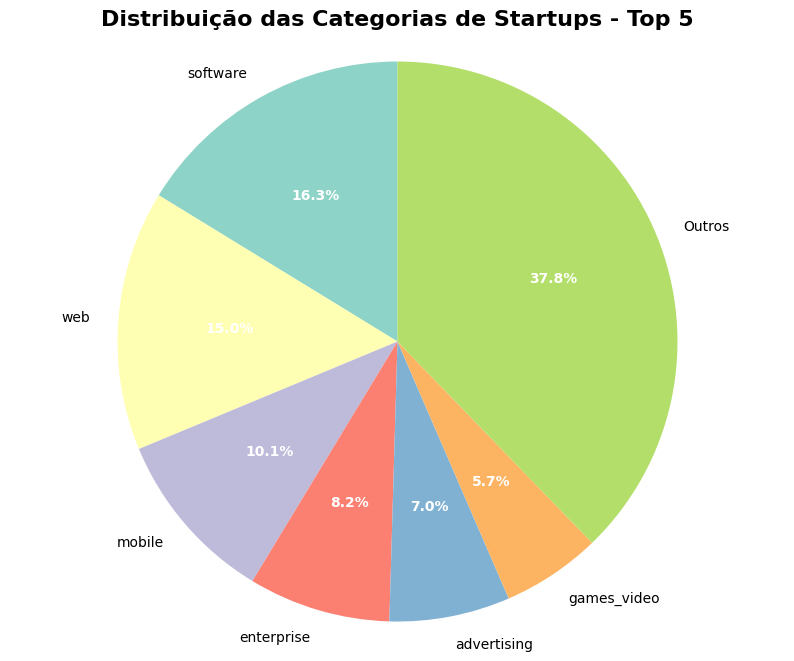

In [11]:
# Pegar apenas as 5 categorias mais frequentes
top_6 = freq_category_code.head(6)
outros = freq_category_code[6:].sum()

# Criar novos dados com "Outros" agrupado
labels_top6 = list(top_6.keys()) + ['Outros']
sizes_top6 = list(top_6.values) + [outros]

# Criar o gráfico melhorado
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(range(len(labels_top6)))
wedges, texts, autotexts = plt.pie(sizes_top6, labels=labels_top6, autopct='%1.1f%%', 
                                   colors=colors, startangle=90)

# Melhorar a legibilidade
plt.title('Distribuição das Categorias de Startups - Top 5', fontsize=16, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.axis('equal')
plt.show()

- #### **Aplicando agrupamento das demais categorias + One Hot Encoding**

Aqui vamos utilizar o agrupamento, pois, além das 5 colunas mais frequentes existem muitas categorias chamadas "Raras" que tem pouca frequência de aparição.

Por conta dessa caracteristica, agruparemos todas as categorias raras na categoria "outros"

**A. Identificando as top 6 categorias mais frequentes**

In [12]:
# Agrupamento + One-Hot Encoding

top_6_categories = freq_category_code.head(6).index.tolist()
print("Top 6 categorias mais frequentes:")
for i, cat in enumerate(top_6_categories, 1):
    print(f"{i}. {cat}: {freq_category_code[cat]} ocorrências")

print(f"\nTotal de outras categorias: {len(freq_category_code) - 6}")
print(f"Soma das outras categorias: {freq_category_code[6:].sum()} ocorrências")

Top 6 categorias mais frequentes:
1. software: 105 ocorrências
2. web: 97 ocorrências
3. mobile: 65 ocorrências
4. enterprise: 53 ocorrências
5. advertising: 45 ocorrências
6. games_video: 37 ocorrências

Total de outras categorias: 28
Soma das outras categorias: 244 ocorrências


**B. Criando função para agrupar categorias**

In [13]:
def simplify_category(category):
    """
    Mantém as top 6 categorias e agrupa as demais como 'outros'
    """
    if category in top_6_categories:
        return category
    else:
        return 'outros'

# Aplicar a simplificação nos dados de treino e teste
df_train['category_simplified'] = df_train['category_code'].apply(simplify_category)
df_test['category_simplified'] = df_test['category_code'].apply(simplify_category)

# Verificar a distribuição após simplificação
print("Distribuição das categorias simplificadas:")
print(df_train['category_simplified'].value_counts())

Distribuição das categorias simplificadas:
category_simplified
outros         244
software       105
web             97
mobile          65
enterprise      53
advertising     45
games_video     37
Name: count, dtype: int64


**C. Aplicar One-Hot Encoding nas categorias simplificadas**

In [14]:
# One-Hot Encoding no conjunto de treino
df_train_encoded = pd.get_dummies(df_train, columns=['category_simplified'], prefix='category')

# One-Hot Encoding no conjunto de teste
df_test_encoded = pd.get_dummies(df_test, columns=['category_simplified'], prefix='category')

print("Colunas criadas pelo One-Hot Encoding:")
category_columns = [col for col in df_train_encoded.columns if col.startswith('category_')]
for col in category_columns:
    print(f"- {col}")

Colunas criadas pelo One-Hot Encoding:
- category_code
- category_advertising
- category_enterprise
- category_games_video
- category_mobile
- category_outros
- category_software
- category_web


**D. Garantir que treino e teste tenham as mesmas colunas**

In [15]:
# Verificar se há diferenças entre as colunas de categoria
train_category_cols = set([col for col in df_train_encoded.columns if col.startswith('category_')])
test_category_cols = set([col for col in df_test_encoded.columns if col.startswith('category_')])

print("Verificação de consistência entre treino e teste:")
print(f"Colunas no treino: {len(train_category_cols)}")
print(f"Colunas no teste: {len(test_category_cols)}")

# Adicionar colunas ausentes no teste (se houver)
missing_in_test = train_category_cols - test_category_cols
if missing_in_test:
    print(f"Colunas ausentes no teste: {missing_in_test}")
    for col in missing_in_test:
        df_test_encoded[col] = 0
else:
    print("✓ Todas as colunas de categoria estão presentes em ambos os conjuntos")

# Garantir mesma ordem de colunas
df_test_encoded = df_test_encoded.reindex(columns=df_train_encoded.columns, fill_value=0)

Verificação de consistência entre treino e teste:
Colunas no treino: 8
Colunas no teste: 8
✓ Todas as colunas de categoria estão presentes em ambos os conjuntos


**E. Visualizar o resultado final**

In [16]:
print("=== RESULTADO DO AGRUPAMENTO + ONE-HOT ENCODING ===")
print(f"\nShape original do treino: {df_train.shape}")
print(f"Shape após encoding do treino: {df_train_encoded.shape}")
print(f"\nShape original do teste: {df_test.shape}")
print(f"Shape após encoding do teste: {df_test_encoded.shape}")

print(f"\nNúmero de colunas categóricas criadas: {len(category_columns)}")
print("\nColunas categóricas finais:")
for col in sorted(category_columns):
    train_sum = df_train_encoded[col].sum()
    test_sum = df_test_encoded[col].sum()
    print(f"  {col}: {train_sum} no treino, {test_sum} no teste")

=== RESULTADO DO AGRUPAMENTO + ONE-HOT ENCODING ===

Shape original do treino: (646, 34)
Shape após encoding do treino: (646, 40)

Shape original do teste: (277, 33)
Shape após encoding do teste: (277, 40)

Número de colunas categóricas criadas: 8

Colunas categóricas finais:
  category_advertising: 45 no treino, 17 no teste
  category_code: enterpriseadvertisingphoto_videoadvertisingwebsoftwaresoftwaresoftwaregames_videomobilesportswebenterprisefashionsoftwarewebsoftwareadvertisingwebenterprisesemiconductorsoftwaresecuritybiotechwebsoftwaresemiconductorhardwarepublic_relationsecommerceadvertisingwebsoftwareenterprisepublic_relationswebotherwebsocialenterprisesoftwarewebsecurityadvertisingwebgames_videosoftwaregames_videogames_videosoftwareadvertisingcleantechmobilehardwarebiotechenterprisewebenterprisewebwebmobilesoftwareenterpriseenterpriseenterprisewebmanufacturingmobilewebsoftwarewebenterprisesemiconductorbiotechwebpublic_relationsmobilegames_videomobilebiotechsoftwareecommercesoft

- Fazendo uma Análise da distribuição da variável target (usando df_train original)

Usando coluna target: labels
Valores únicos: [0 1]


C:\Users\Inteli\AppData\Local\Temp\ipykernel_45868\4235851160.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Insucesso (0)', 'Sucesso (1)'])


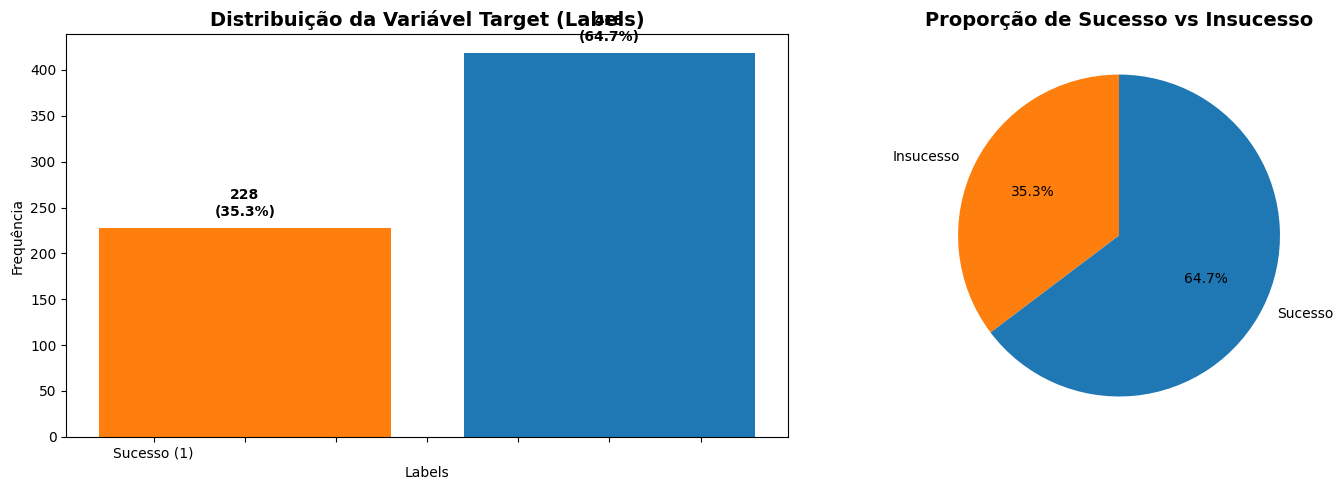

Taxa de sucesso das startups: 64.71%
Total de startups: 646
Startups com sucesso: 418
Startups com insucesso: 228
Balanceamento dos dados: Desbalanceado


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# A coluna target é 'labels'
target_column = 'labels'
if target_column in df_train.columns:
    target_counts = df_train[target_column].value_counts().sort_index()
    print(f"Usando coluna target: {target_column}")
    print(f"Valores únicos: {df_train[target_column].unique()}")

# Gráfico de contagem
ax1.bar(target_counts.index, target_counts.values, color=['#ff7f0e', '#1f77b4'])
ax1.set_title('Distribuição da Variável Target (Labels)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Labels')
ax1.set_ylabel('Frequência')
ax1.set_xticklabels(['Insucesso (0)', 'Sucesso (1)'])

# Adicionar percentuais nas barras
for i, v in enumerate(target_counts.values):
    ax1.text(i, v + 10, f'{v}\n({v/len(df_train)*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

# Gráfico de pizza
colors = ['#ff7f0e', '#1f77b4']
wedges, texts, autotexts = ax2.pie(target_counts.values, labels=['Insucesso', 'Sucesso'], 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Proporção de Sucesso vs Insucesso', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Taxa de sucesso das startups: {target_counts[1]/len(df_train)*100:.2f}%")
print(f"Total de startups: {len(df_train)}")
print(f"Startups com sucesso: {target_counts[1]}")
print(f"Startups com insucesso: {target_counts[0]}")
print(f"Balanceamento dos dados: {'Desbalanceado' if abs(target_counts[0] - target_counts[1])/len(df_train) > 0.1 else 'Relativamente balanceado'}")

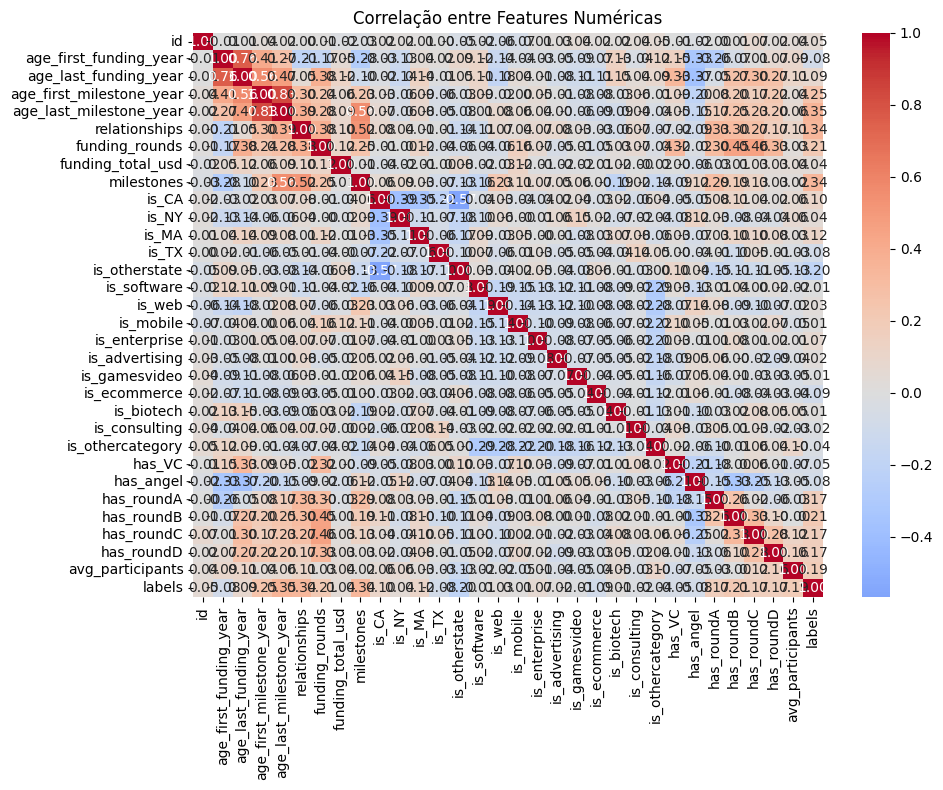

In [18]:
# 5. Correlação Simples (apenas features numéricas)

# Pegar apenas colunas numéricas
numeric_cols = df_train_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Remover colunas categóricas criadas
numeric_cols = [col for col in numeric_cols if not col.startswith('category_')]

# Matriz de correlação simples
plt.figure(figsize=(10, 8))
corr_matrix = df_train_encoded[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlação entre Features Numéricas')
plt.tight_layout()
plt.show()

#### **4. Análise Exploratória Avançada**

Aqui vamos analisar o comportamento das features numéricas em relação ao target, identificando padrões que podem indicar sucesso ou insucesso das startups.

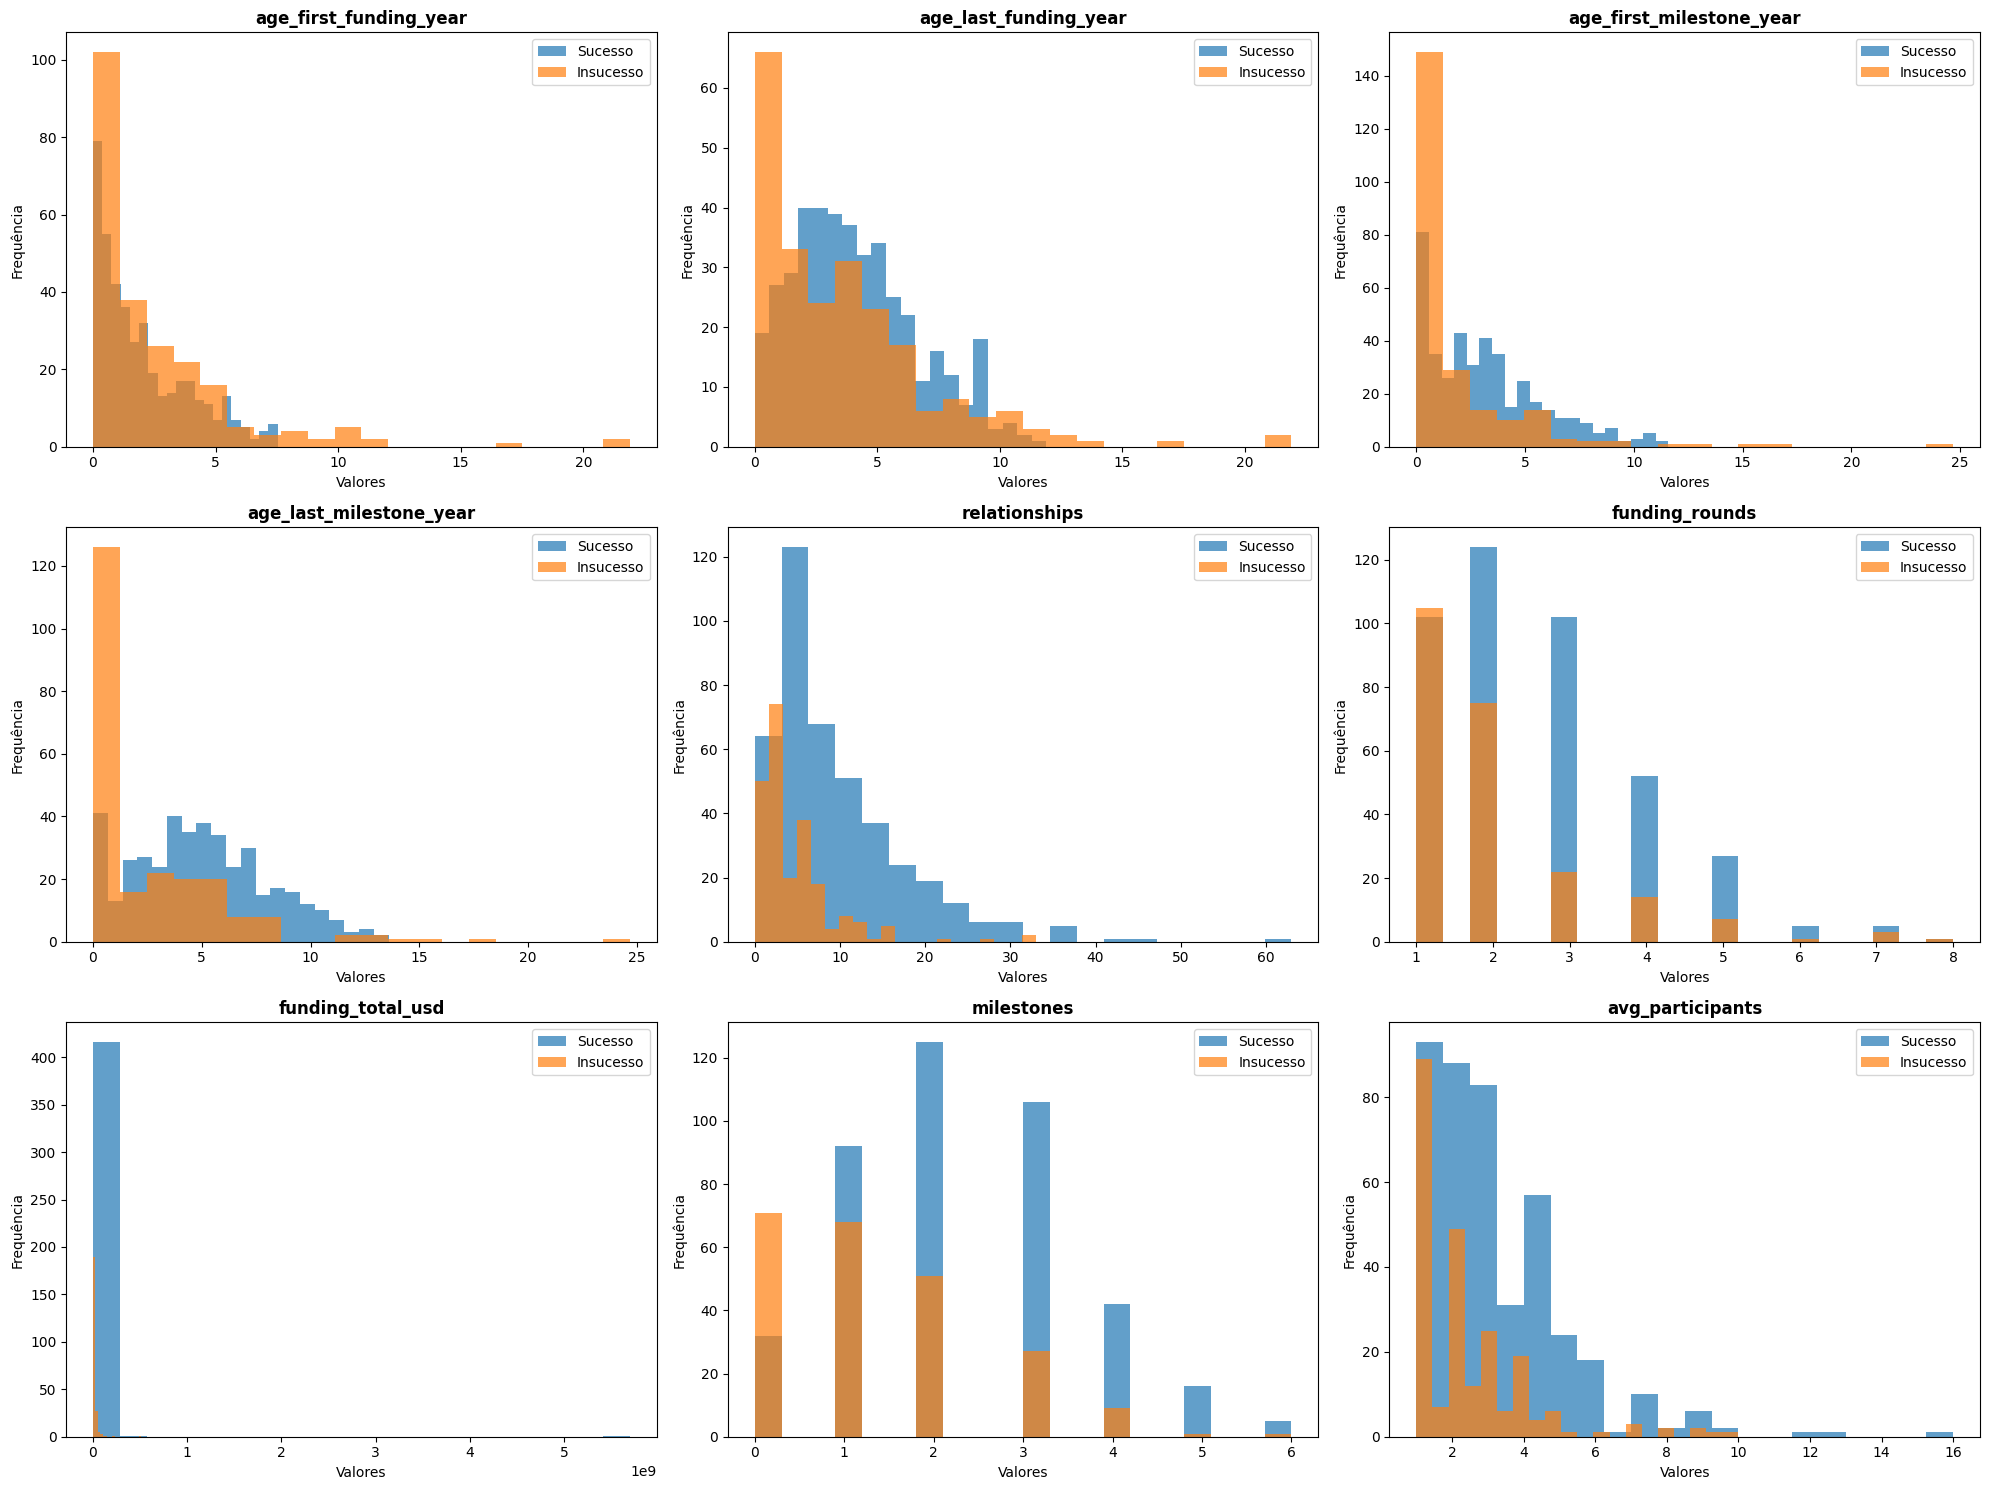

=== ESTATÍSTICAS POR CLASSE ===
age_first_funding_year:
  Sucesso: 2.06
  Insucesso: 2.49
  Diferença: -0.43

age_last_funding_year:
  Sucesso: 4.17
  Insucesso: 3.64
  Diferença: 0.53

age_first_milestone_year:
  Sucesso: 3.17
  Insucesso: 1.67
  Diferença: 1.50

age_last_milestone_year:
  Sucesso: 5.00
  Insucesso: 2.44
  Diferença: 2.55

relationships:
  Sucesso: 9.82
  Insucesso: 4.52
  Diferença: 5.30

funding_rounds:
  Sucesso: 2.56
  Insucesso: 1.96
  Diferença: 0.60

funding_total_usd:
  Sucesso: 36786577.99
  Insucesso: 16130874.94
  Diferença: 20655703.05

milestones:
  Sucesso: 2.24
  Insucesso: 1.31
  Diferença: 0.94

avg_participants:
  Sucesso: 3.12
  Insucesso: 2.35
  Diferença: 0.77



In [19]:
# 4.1 Análise de Features Numéricas vs Target
numeric_features = ['age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 
                   'age_last_milestone_year', 'relationships', 'funding_rounds', 
                   'funding_total_usd', 'milestones', 'avg_participants']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.ravel()

for i, feature in enumerate(numeric_features):
    # Remover NaN para visualização
    data_clean = df_train[df_train[feature].notna()]
    
    success = data_clean[data_clean['labels'] == 1][feature]
    failure = data_clean[data_clean['labels'] == 0][feature]
    
    axes[i].hist(success, alpha=0.7, label='Sucesso', bins=20, color='#1f77b4')
    axes[i].hist(failure, alpha=0.7, label='Insucesso', bins=20, color='#ff7f0e')
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel('Valores')
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# Estatísticas descritivas por target
print("=== ESTATÍSTICAS POR CLASSE ===")
for feature in numeric_features:
    data_clean = df_train[df_train[feature].notna()]
    success_mean = data_clean[data_clean['labels'] == 1][feature].mean()
    failure_mean = data_clean[data_clean['labels'] == 0][feature].mean()
    
    print(f"{feature}:")
    print(f"  Sucesso: {success_mean:.2f}")
    print(f"  Insucesso: {failure_mean:.2f}")
    print(f"  Diferença: {success_mean - failure_mean:.2f}")
    print()

#### **5. Análise de Features Categóricas**

Análise do impacto das variáveis categóricas (localização, setor, tipos de financiamento) na taxa de sucesso das startups.

- 5.1 Análise das features de localização

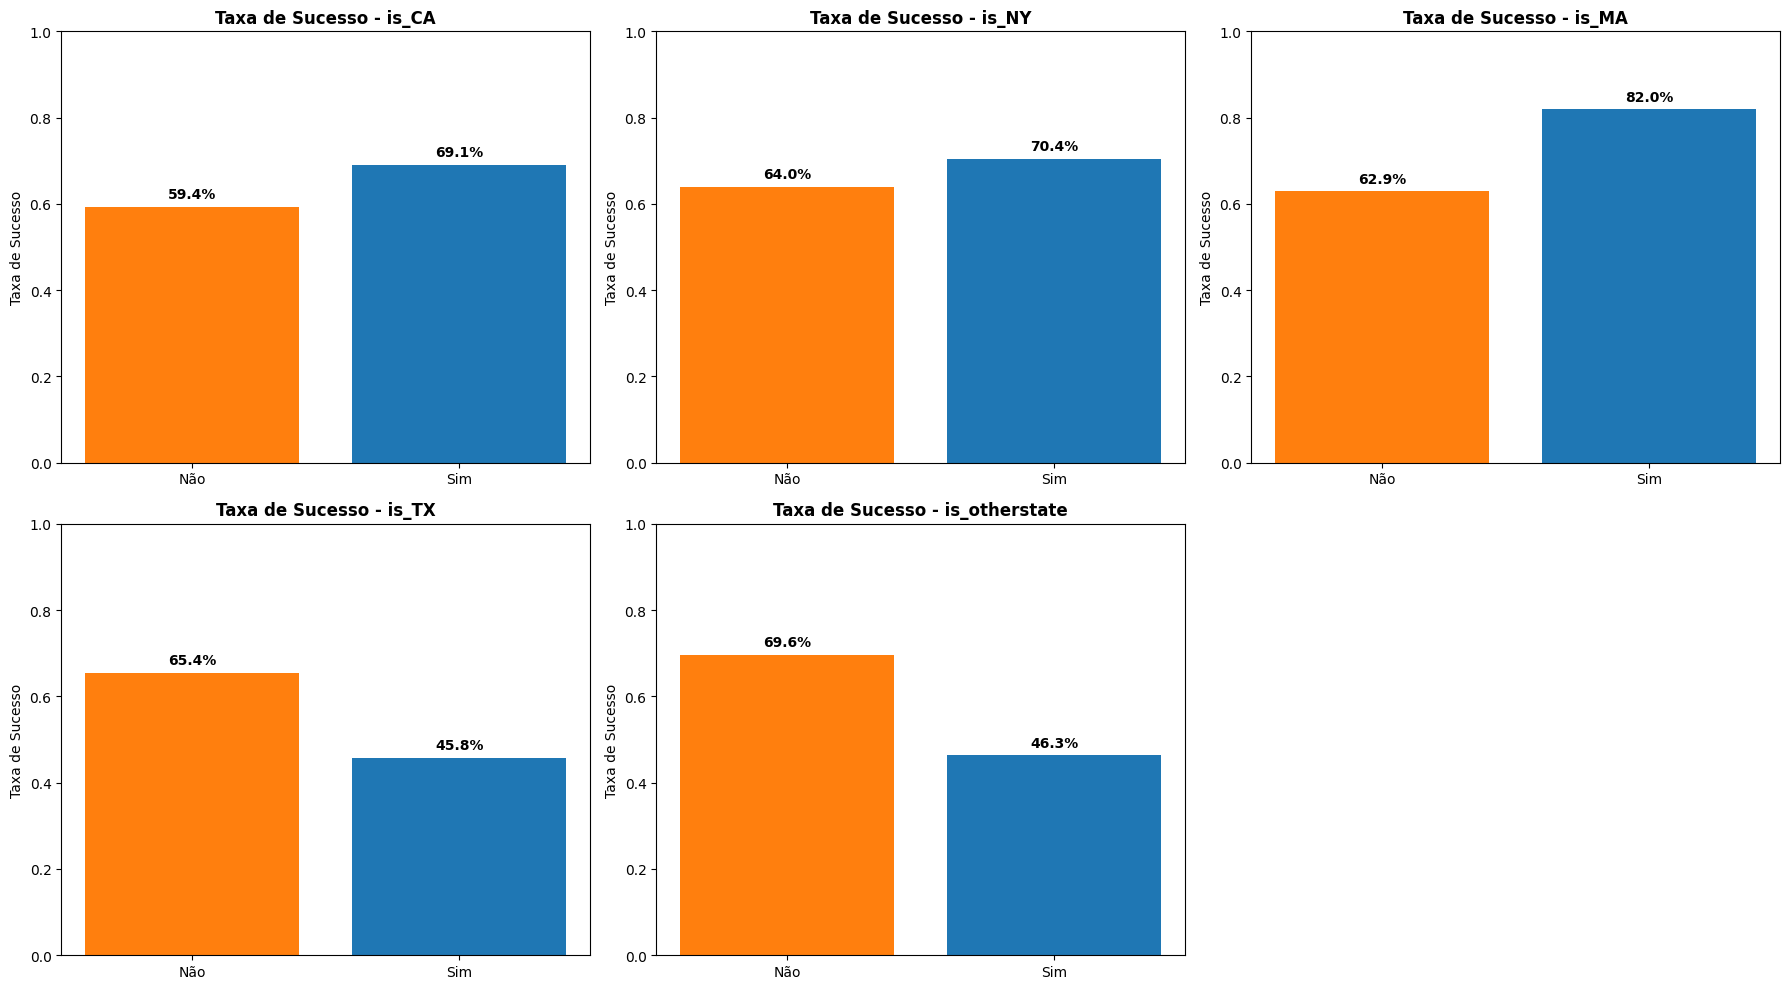

In [20]:
location_features = ['is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feature in enumerate(location_features):
    cross_tab = pd.crosstab(df_train[feature], df_train['labels'])
    success_rate = cross_tab[1] / cross_tab.sum(axis=1)
    
    axes[i].bar(['Não', 'Sim'], success_rate, color=['#ff7f0e', '#1f77b4'])
    axes[i].set_title(f'Taxa de Sucesso - {feature}', fontweight='bold')
    axes[i].set_ylabel('Taxa de Sucesso')
    axes[i].set_ylim(0, 1)
    
    # Adicionar percentuais
    for j, v in enumerate(success_rate):
        axes[i].text(j, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Remover subplot extra
axes[5].remove()
plt.tight_layout()
plt.show()

- 5.2 Análise das features de setor

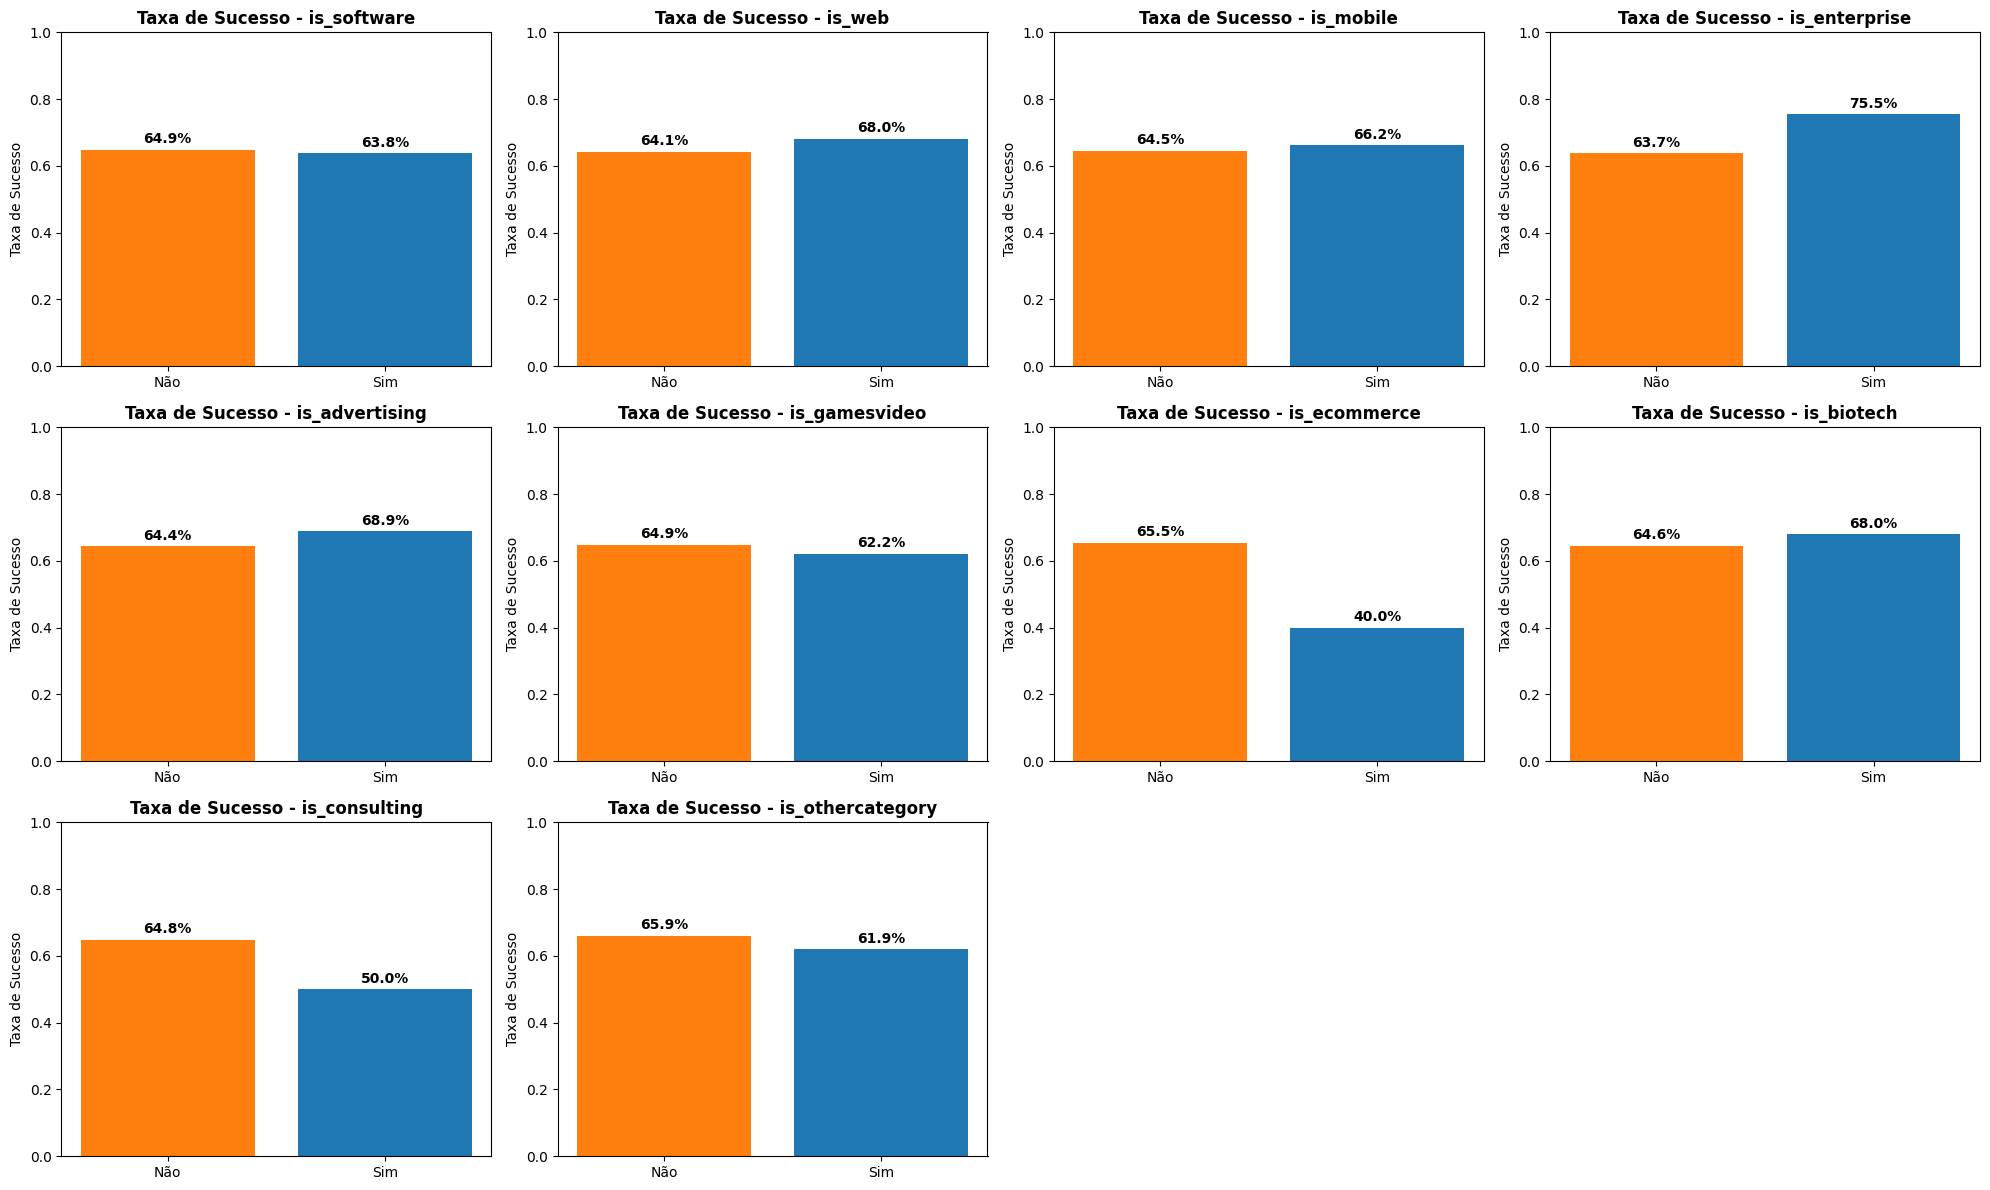

In [21]:
sector_features = ['is_software', 'is_web', 'is_mobile', 'is_enterprise', 
                  'is_advertising', 'is_gamesvideo', 'is_ecommerce', 
                  'is_biotech', 'is_consulting', 'is_othercategory']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for i, feature in enumerate(sector_features):
    cross_tab = pd.crosstab(df_train[feature], df_train['labels'])
    success_rate = cross_tab[1] / cross_tab.sum(axis=1)
    
    axes[i].bar(['Não', 'Sim'], success_rate, color=['#ff7f0e', '#1f77b4'])
    axes[i].set_title(f'Taxa de Sucesso - {feature}', fontweight='bold')
    axes[i].set_ylabel('Taxa de Sucesso')
    axes[i].set_ylim(0, 1)
    
    # Adicionar percentuais
    for j, v in enumerate(success_rate):
        axes[i].text(j, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Remover subplots extras
for j in range(len(sector_features), 12):
    axes[j].remove()
    
plt.tight_layout()
plt.show()

#### **6. Identificando Correlações com a Target**

Identificação das features mais correlacionadas com o sucesso das startups.

C:\Users\Inteli\AppData\Local\Temp\ipykernel_45868\481031359.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_correlations.index, x=top_correlations.values, palette='viridis')


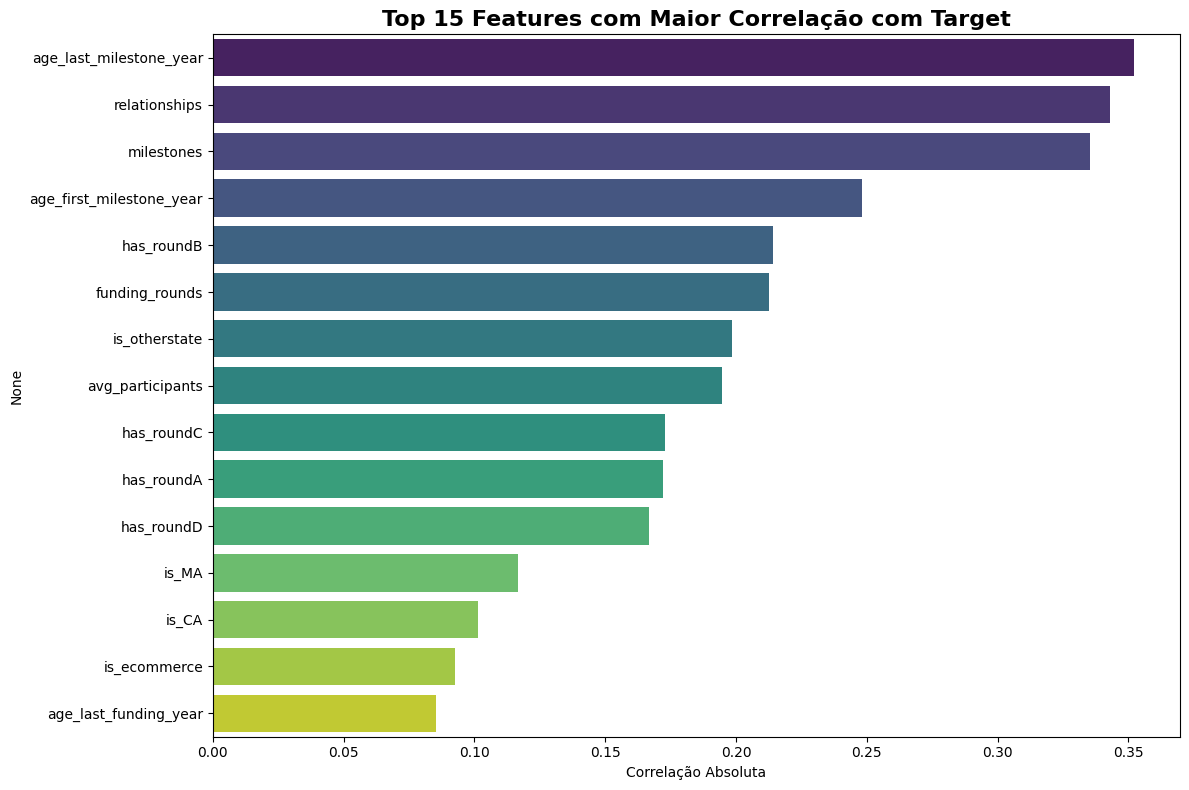

=== TOP 15 CORRELAÇÕES COM TARGET ===
 1. age_last_milestone_year: 0.352
 2. relationships: 0.343
 3. milestones: 0.335
 4. age_first_milestone_year: 0.248
 5. has_roundB: 0.214
 6. funding_rounds: 0.213
 7. is_otherstate: 0.199
 8. avg_participants: 0.194
 9. has_roundC: 0.173
10. has_roundA: 0.172
11. has_roundD: 0.167
12. is_MA: 0.117
13. is_CA: 0.101
14. is_ecommerce: 0.092
15. age_last_funding_year: 0.086

Colunas não numéricas removidas da análise: ['category_code', 'category_advertising', 'category_enterprise', 'category_games_video', 'category_mobile', 'category_outros', 'category_software', 'category_web']


In [22]:
# 6.1 Correlação com a variável target
# Remover colunas não numéricas para o cálculo de correlação
numeric_df = df_train_encoded.select_dtypes(include=[np.number])

target_correlations = numeric_df.corr()['labels'].abs().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
top_correlations = target_correlations[1:16]  # Top 15 (excluindo a própria target)
sns.barplot(y=top_correlations.index, x=top_correlations.values, palette='viridis')
plt.title('Top 15 Features com Maior Correlação com Target', fontsize=16, fontweight='bold')
plt.xlabel('Correlação Absoluta')
plt.tight_layout()
plt.show()

print("=== TOP 15 CORRELAÇÕES COM TARGET ===")
for i, (feature, corr) in enumerate(top_correlations.head(15).items(), 1):
    print(f"{i:2d}. {feature}: {corr:.3f}")

# Verificar se há colunas não numéricas
non_numeric_cols = df_train_encoded.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nColunas não numéricas removidas da análise: {non_numeric_cols}")


#### **7. Preparação Final para Modelagem**

Separação final dos dados para aplicação dos algoritmos de machine learning.

In [23]:
# 7.1 Separação de features e target
X = df_train_encoded.drop(['labels', 'category_code'], axis=1, errors='ignore')
y = df_train_encoded['labels']

X_test = df_test_encoded.drop(['category_code'], axis=1, errors='ignore')

print("=== PREPARAÇÃO FINAL ===")
print(f"Shape do conjunto de treino: {X.shape}")
print(f"Shape do conjunto de teste: {X_test.shape}")
print(f"Shape do target: {y.shape}")

print(f"\nDistribuição do target:")
print(f"Classe 0 (Insucesso): {(y == 0).sum()} ({(y == 0).mean():.1%})")
print(f"Classe 1 (Sucesso): {(y == 1).sum()} ({(y == 1).mean():.1%})")

# Verificar se as colunas são consistentes
print(f"\nColunas consistentes entre treino e teste: {set(X.columns) == set(X_test.columns)}")

=== PREPARAÇÃO FINAL ===
Shape do conjunto de treino: (646, 38)
Shape do conjunto de teste: (277, 39)
Shape do target: (646,)

Distribuição do target:
Classe 0 (Insucesso): 228 (35.3%)
Classe 1 (Sucesso): 418 (64.7%)

Colunas consistentes entre treino e teste: False


#### **8. Formulando Hipóteses**

Com base na análise exploratória realizada, foi possivel formular as seguintes hipóteses sobre os fatores que influenciam o sucesso das startups:

In [24]:
print("=== HIPÓTESES FORMULADAS ===")
print()
print("H1: HIPÓTESE DO FINANCIAMENTO")
print("Startups com maior volume de captação (funding_total_usd) e mais rodadas")
print("de financiamento (funding_rounds) têm maior probabilidade de sucesso.")
print("Justificativa: Recursos financeiros permitem crescimento e sustentabilidade.")
print()

print("H2: HIPÓTESE DA REDE DE RELACIONAMENTOS") 
print("Startups com mais relacionamentos (relationships) e maior média de")
print("participantes por rodada (avg_participants) têm maior chance de sucesso.")
print("Justificativa: Networking amplo indica maior suporte e oportunidades.")
print()

print("H3: HIPÓTESE GEOGRÁFICA E SETORIAL")
print("Startups localizadas em hubs tecnológicos (is_CA, is_NY, is_MA) e")
print("do setor de software/web têm maior probabilidade de sucesso.")
print("Justificativa: Ecossistemas maduros oferecem mais recursos e mercado.")

=== HIPÓTESES FORMULADAS ===

H1: HIPÓTESE DO FINANCIAMENTO
Startups com maior volume de captação (funding_total_usd) e mais rodadas
de financiamento (funding_rounds) têm maior probabilidade de sucesso.
Justificativa: Recursos financeiros permitem crescimento e sustentabilidade.

H2: HIPÓTESE DA REDE DE RELACIONAMENTOS
Startups com mais relacionamentos (relationships) e maior média de
participantes por rodada (avg_participants) têm maior chance de sucesso.
Justificativa: Networking amplo indica maior suporte e oportunidades.

H3: HIPÓTESE GEOGRÁFICA E SETORIAL
Startups localizadas em hubs tecnológicos (is_CA, is_NY, is_MA) e
do setor de software/web têm maior probabilidade de sucesso.
Justificativa: Ecossistemas maduros oferecem mais recursos e mercado.


#### **9. Seleção de Features**

Com base nas correlações encontradas e nas hipóteses formuladas, selecionarei as features mais relevantes:

In [25]:
# 9.1 Seleção baseada em correlação e hipóteses
print("=== SELEÇÃO DE FEATURES ===")

# Features com alta correlação (>0.1)
high_corr_features = target_correlations[target_correlations > 0.1].index.tolist()
print(f"Features com correlação > 0.1: {high_corr_features}")

# Features das hipóteses
hypothesis_features = [
    'funding_total_usd', 'funding_rounds',  # H1
    'relationships', 'avg_participants',     # H2  
    'is_CA', 'is_NY', 'is_MA', 'is_software', 'is_web'  # H3
]

# Combinando e remover duplicatas
selected_features = list(set(high_corr_features + hypothesis_features))
if 'labels' in selected_features:
    selected_features.remove('labels')

print(f"Features selecionadas ({len(selected_features)}): {selected_features}")

# Criando datasets com features selecionadas
X_selected = X[selected_features]
X_test_selected = X_test[selected_features]

print(f"Shape após seleção - Treino: {X_selected.shape}, Teste: {X_test_selected.shape}")

=== SELEÇÃO DE FEATURES ===
Features com correlação > 0.1: ['labels', 'age_last_milestone_year', 'relationships', 'milestones', 'age_first_milestone_year', 'has_roundB', 'funding_rounds', 'is_otherstate', 'avg_participants', 'has_roundC', 'has_roundA', 'has_roundD', 'is_MA', 'is_CA']
Features selecionadas (17): ['avg_participants', 'has_roundD', 'age_first_milestone_year', 'has_roundB', 'relationships', 'funding_total_usd', 'is_web', 'is_NY', 'is_software', 'is_otherstate', 'has_roundA', 'is_MA', 'milestones', 'age_last_milestone_year', 'is_CA', 'has_roundC', 'funding_rounds']
Shape após seleção - Treino: (646, 17), Teste: (277, 17)


#### **10. Construção e Avaliação do Modelo**

Implementação e comparação de diferentes algoritmos de machine learning para encontrar o melhor modelo para predição do sucesso de startups.

In [27]:
# Importar bibliotecas necessárias

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas")

Bibliotecas importadas


- **10.1 Divisão dos dados para validação**

Aqui separamos o dataframe de testes.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print("=== DIVISÃO DOS DADOS ===")
print(f"Conjunto de treino: {X_train.shape}")
print(f"Conjunto de validação: {X_val.shape}")
print(f"Distribuição do treino: {y_train.value_counts().to_dict()}")
print(f"Distribuição da validação: {y_val.value_counts().to_dict()}")

=== DIVISÃO DOS DADOS ===
Conjunto de treino: (516, 17)
Conjunto de validação: (130, 17)
Distribuição do treino: {1: 334, 0: 182}
Distribuição da validação: {1: 84, 0: 46}


- **10.2 Preparação dos modelos para comparação**

Aqui estamos selecionando 6 tipos de modelos para que possamos ter uma abrangência de resultados e que possamos, no fim, escolher aquele com melhor resultado.

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

# Para modelos que precisam de escalonamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("=== MODELOS PREPARADOS ===")
for name in models.keys():
    print(f"✓ {name}")

=== MODELOS PREPARADOS ===
✓ Random Forest
✓ Gradient Boosting
✓ Logistic Regression
✓ SVM
✓ KNN
✓ Naive Bayes


- **10.3 Treinamento e avaliação inicial dos modelos**

Aqui estamos fazendo o código específico para cada modelo, aplicando o teste e visualizando o resultado inicial.

In [ ]:
results = {}
cv_results = {}

print("=== AVALIAÇÃO INICIAL DOS MODELOS ===")
print("Modelo\t\t\tAcurácia\tAUC-ROC\t\tCV Score")
print("-" * 70)

# Validação crusada:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Decidir se usar dados escalonados ou não
    if name in ['Logistic Regression', 'SVM', 'KNN']:
        X_train_use = X_train_scaled
        X_val_use = X_val_scaled
        X_cv_use = X_selected
        # Para CV, vamos escalonar também
        X_cv_scaled = StandardScaler().fit_transform(X_cv_use)
        cv_scores = cross_val_score(model, X_cv_scaled, y, cv=cv, scoring='accuracy')
    else:
        X_train_use = X_train
        X_val_use = X_val
        cv_scores = cross_val_score(model, X_selected, y, cv=cv, scoring='accuracy')
    
    # Treinar modelo
    model.fit(X_train_use, y_train)
    
    # Predições
    y_pred = model.predict(X_val_use)
    y_pred_proba = model.predict_proba(X_val_use)[:, 1]
    
    # Métricas
    accuracy = accuracy_score(y_val, y_pred)
    auc_roc = roc_auc_score(y_val, y_pred_proba)
    cv_mean = cv_scores.mean()
    
    # Armazenar resultados
    results[name] = {
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'cv_mean': cv_mean,
        'cv_std': cv_scores.std(),
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"{name:<20}\t{accuracy:.4f}\t\t{auc_roc:.4f}\t\t{cv_mean:.4f} ± {cv_scores.std():.4f}")

=== AVALIAÇÃO INICIAL DOS MODELOS ===
Modelo			Acurácia	AUC-ROC		CV Score
----------------------------------------------------------------------
Random Forest       	0.7769		0.7946		0.7708 ± 0.0401
Gradient Boosting   	0.8000		0.8196		0.7832 ± 0.0267
Logistic Regression 	0.7538		0.8116		0.7445 ± 0.0373
SVM                 	0.7462		0.7629		0.7522 ± 0.0358
KNN                 	0.6846		0.7192		0.7182 ± 0.0341
Naive Bayes         	0.3769		0.4200		0.4227 ± 0.1097


- **10.4 Análise detalhada do melhor modelo**

Diferentemente do bloco anterior, agora vamos fazer uma análise detalhada e focar no melhor resultado inicial

In [ ]:
best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
best_model_results = results[best_model_name]

print(f"\n=== MELHOR MODELO: {best_model_name.upper()} ===")
print(f"Acurácia: {best_model_results['accuracy']:.4f}")
print(f"AUC-ROC: {best_model_results['auc_roc']:.4f}")
print(f"Cross-Validation: {best_model_results['cv_mean']:.4f} ± {best_model_results['cv_std']:.4f}")

# Classification Report
print(f"\n=== CLASSIFICATION REPORT - {best_model_name} ===")
print(classification_report(y_val, best_model_results['y_pred'], 
                          target_names=['Insucesso', 'Sucesso']))


=== MELHOR MODELO: GRADIENT BOOSTING ===
Acurácia: 0.8000
AUC-ROC: 0.8196
Cross-Validation: 0.7832 ± 0.0267

=== CLASSIFICATION REPORT - Gradient Boosting ===
              precision    recall  f1-score   support

   Insucesso       0.78      0.61      0.68        46
     Sucesso       0.81      0.90      0.85        84

    accuracy                           0.80       130
   macro avg       0.79      0.76      0.77       130
weighted avg       0.80      0.80      0.79       130



- **10.5 Matriz de Confusão e Visualizações do melhor modelo inicial**

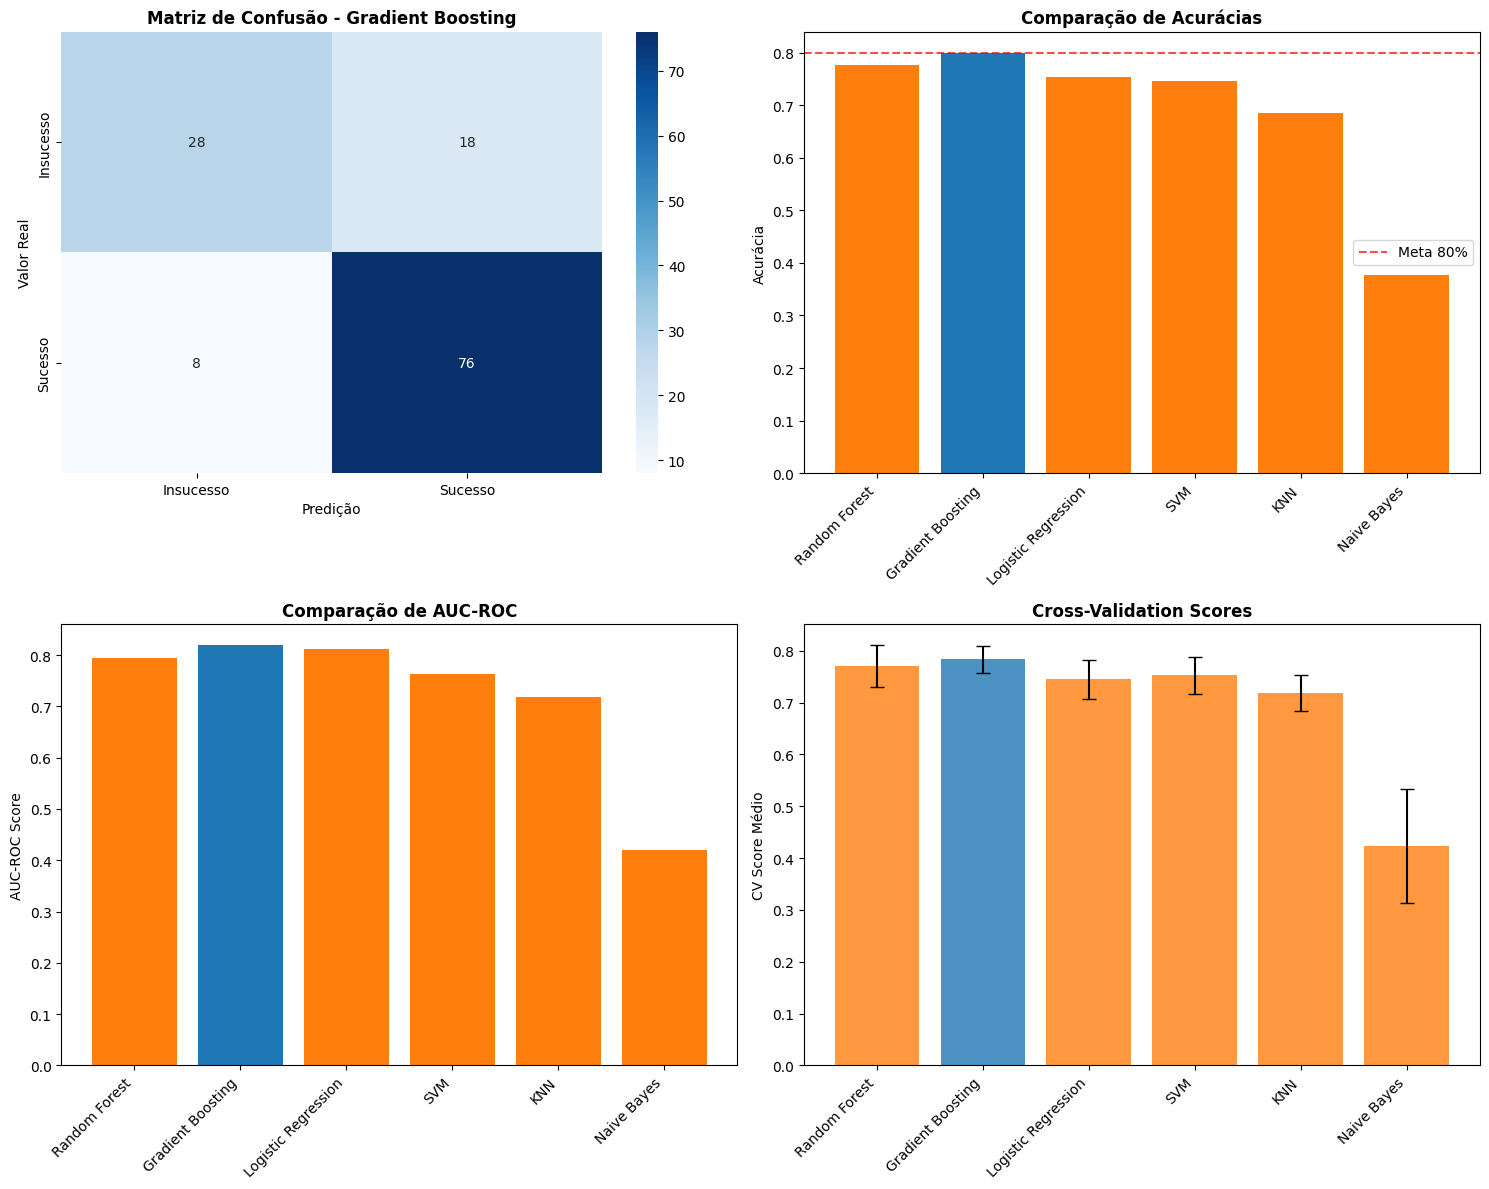

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Matriz de Confusão
cm = confusion_matrix(y_val, best_model_results['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
           xticklabels=['Insucesso', 'Sucesso'], 
           yticklabels=['Insucesso', 'Sucesso'])
axes[0,0].set_title(f'Matriz de Confusão - {best_model_name}', fontweight='bold')
axes[0,0].set_ylabel('Valor Real')
axes[0,0].set_xlabel('Predição')

# Comparação de Acurácias
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]
colors = ['#1f77b4' if name == best_model_name else '#ff7f0e' for name in model_names]

axes[0,1].bar(range(len(model_names)), accuracies, color=colors)
axes[0,1].set_title('Comparação de Acurácias', fontweight='bold')
axes[0,1].set_ylabel('Acurácia')
axes[0,1].set_xticks(range(len(model_names)))
axes[0,1].set_xticklabels(model_names, rotation=45, ha='right')
axes[0,1].axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Meta 80%')
axes[0,1].legend()

# AUC-ROC Comparison
auc_scores = [results[name]['auc_roc'] for name in model_names]
axes[1,0].bar(range(len(model_names)), auc_scores, color=colors)
axes[1,0].set_title('Comparação de AUC-ROC', fontweight='bold')
axes[1,0].set_ylabel('AUC-ROC Score')
axes[1,0].set_xticks(range(len(model_names)))
axes[1,0].set_xticklabels(model_names, rotation=45, ha='right')

# Cross-Validation Scores
cv_means = [results[name]['cv_mean'] for name in model_names]
cv_stds = [results[name]['cv_std'] for name in model_names]
axes[1,1].bar(range(len(model_names)), cv_means, yerr=cv_stds, 
             capsize=5, color=colors, alpha=0.8)
axes[1,1].set_title('Cross-Validation Scores', fontweight='bold')
axes[1,1].set_ylabel('CV Score Médio')
axes[1,1].set_xticks(range(len(model_names)))
axes[1,1].set_xticklabels(model_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

- **10.6 Verificando a correlação e importância de cada feature no melhor modelo inicial**

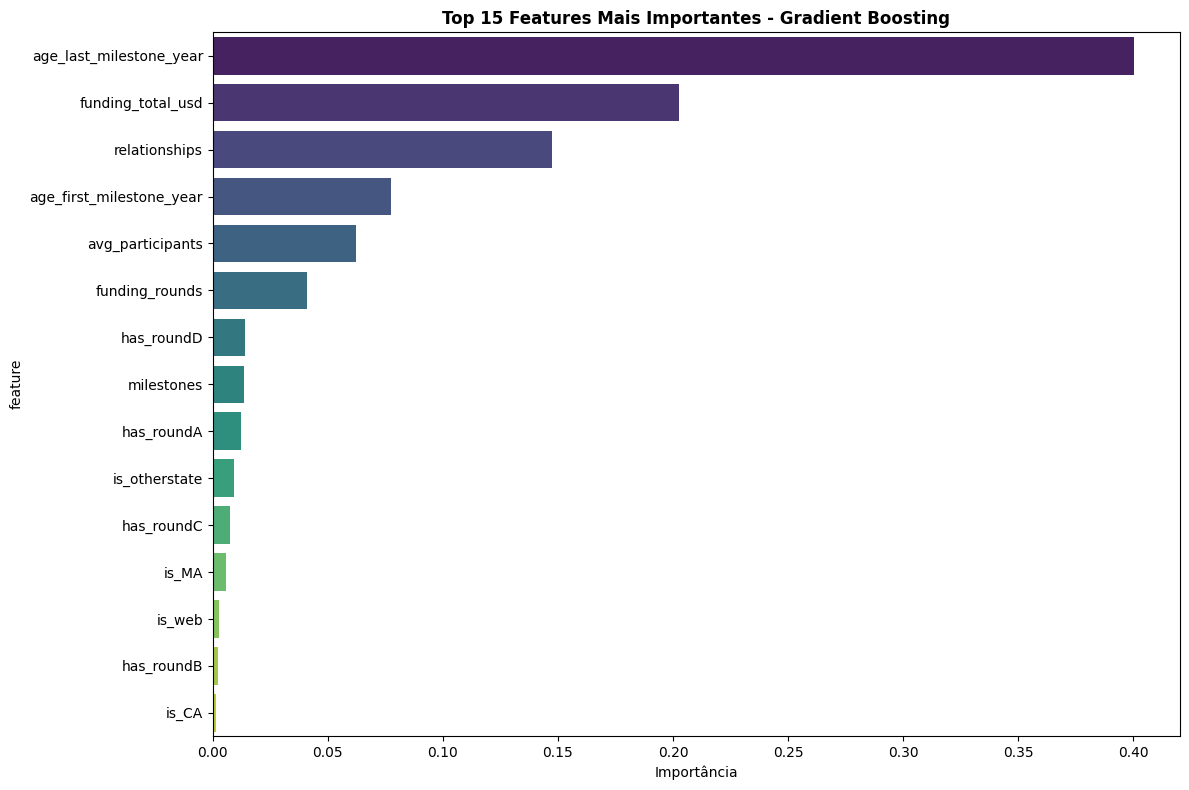

=== TOP 10 FEATURES MAIS IMPORTANTES ===
 1. age_last_milestone_year: 0.4003
 2. funding_total_usd: 0.2024
 3. relationships: 0.1476
 4. age_first_milestone_year: 0.0775
 5. avg_participants: 0.0622
 6. funding_rounds: 0.0411
 7. has_roundD: 0.0141
 8. milestones: 0.0136
 9. has_roundA: 0.0122
10. is_otherstate: 0.0090


In [ ]:
if hasattr(best_model_results['model'], 'feature_importances_'):
    feature_importance = best_model_results['model'].feature_importances_
    feature_names = X_selected.columns
    
    # Criando DataFrame para facilitar ordenação
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df.head(15), y='feature', x='importance', palette='viridis')
    plt.title(f'Top 15 Features Mais Importantes - {best_model_name}', fontweight='bold')
    plt.xlabel('Importância')
    plt.tight_layout()
    plt.show()
    
    print("=== TOP 10 FEATURES MAIS IMPORTANTES ===")
    for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
        print(f"{i:2d}. {row['feature']}: {row['importance']:.4f}")
        
elif hasattr(best_model_results['model'], 'coef_'):
    # Para modelos lineares
    coef = best_model_results['model'].coef_[0]
    feature_names = X_selected.columns
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': abs(coef)
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df.head(15), y='feature', x='importance', palette='viridis')
    plt.title(f'Top 15 Features Mais Importantes - {best_model_name}', fontweight='bold')
    plt.xlabel('Importância (|Coeficiente|)')
    plt.tight_layout()
    plt.show()
    
    print("=== TOP 10 FEATURES MAIS IMPORTANTES ===")
    for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
        print(f"{i:2d}. {row['feature']}: {row['importance']:.4f}")
else:
    print(f"{best_model_name} não suporta análise de importância de features")

- **10.7 Resumo da Avaliação inicial**

In [38]:
print("=" * 80)
print("                        RESUMO DA AVALIAÇÃO INICIAL DE MODELOS")
print("=" * 80)

print(f"\n🏆 MELHOR MODELO: {best_model_name}")
print(f"   Acurácia: {best_model_results['accuracy']:.4f} ({best_model_results['accuracy']*100:.2f}%)")

if best_model_results['accuracy'] >= 0.8:
    print("   ✅ META DE 80% DE ACURÁCIA ATINGIDA!")
else:
    print(f"   ❌ Meta de 80% não atingida (faltam {(0.8 - best_model_results['accuracy'])*100:.2f} pontos percentuais)")

print(f"   AUC-ROC: {best_model_results['auc_roc']:.4f}")
print(f"   Validação Cruzada: {best_model_results['cv_mean']:.4f} ± {best_model_results['cv_std']:.4f}")

print(f"\n📊 RANKING DOS MODELOS (por acurácia):")
ranked_models = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for i, (name, result) in enumerate(ranked_models, 1):
    print(f"   {i}. {name}: {result['accuracy']:.4f}")

                        RESUMO DA AVALIAÇÃO INICIAL DE MODELOS

🏆 MELHOR MODELO: Gradient Boosting
   Acurácia: 0.8000 (80.00%)
   ✅ META DE 80% DE ACURÁCIA ATINGIDA!
   AUC-ROC: 0.8196
   Validação Cruzada: 0.7832 ± 0.0267

📊 RANKING DOS MODELOS (por acurácia):
   1. Gradient Boosting: 0.8000
   2. Random Forest: 0.7769
   3. Logistic Regression: 0.7538
   4. SVM: 0.7462
   5. KNN: 0.6846
   6. Naive Bayes: 0.3769


#### **11. Finetuning de Hiperparâmetros**

Otimização dos hiperparâmetros do melhor modelo identificado para maximizar o desempenho preditivo.

- **11.1 Importar bibliotecas para otimização**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
import time

print("=== INÍCIO DO FINETUNING DE HIPERPARÂMETROS ===")
print(f"Modelo selecionado para otimização: {best_model_name}")
print(f"Acurácia atual (baseline): {best_model_results['accuracy']:.4f}")

=== INÍCIO DO FINETUNING DE HIPERPARÂMETROS ===
Modelo selecionado para otimização: Gradient Boosting
Acurácia atual (baseline): 0.8000


- **11.2 Definir espaços de busca por modelo**

In [ ]:
def get_param_grid(model_name):
    """Define os hiperparâmetros a serem otimizados para cada modelo"""
    
    if model_name == 'Random Forest':
        return {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }
    
    elif model_name == 'Gradient Boosting':
        return {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.05, 0.1, 0.15, 0.2],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    
    elif model_name == 'Logistic Regression':
        return {
            'C': [0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
            'max_iter': [1000, 2000]
        }
    
    elif model_name == 'SVM':
        return {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'poly', 'sigmoid'],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
        }
    
    elif model_name == 'KNN':
        return {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski']
        }
    
    elif model_name == 'Naive Bayes':
        return {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
        }
    
    else:
        return {}

param_grid = get_param_grid(best_model_name)
print(f"Parâmetros a otimizar: {list(param_grid.keys())}")
print(f"Total de combinações: {np.prod([len(v) for v in param_grid.values()])}")

Parâmetros a otimizar: ['n_estimators', 'learning_rate', 'max_depth', 'min_samples_split', 'min_samples_leaf']
Total de combinações: 324


- **11.3 Estratégia de busca inteligente**

In [ ]:
def perform_hyperparameter_tuning(model, param_grid, X_train, y_train, model_name):
    """
    Realiza busca de hiperparâmetros com estratégia adaptativa
    """
    print(f"\n=== OTIMIZAÇÃO DE HIPERPARÂMETROS - {model_name} ===")
    
    # Calcular número total de combinações
    total_combinations = np.prod([len(v) for v in param_grid.values()])
    
    # Escolher estratégia baseada no número de combinações
    if total_combinations <= 100:
        print("📊 Estratégia: Grid Search (busca completa)")
        search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )
    else:
        print("📊 Estratégia: Randomized Search (busca otimizada)")
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            n_iter=50,  # Limitar a 50 tentativas
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='accuracy',
            n_jobs=-1,
            verbose=1,
            random_state=42
        )
    
    # Executar busca
    print(f"🔍 Iniciando busca... (pode levar alguns minutos)")
    start_time = time.time()
    
    search.fit(X_train, y_train)
    
    end_time = time.time()
    print(f"⏱️ Tempo de execução: {end_time - start_time:.2f} segundos")
    
    return search

# Executar otimização
if best_model_name in ['Logistic Regression', 'SVM', 'KNN']:
    X_train_opt = X_train_scaled
    X_val_opt = X_val_scaled
else:
    X_train_opt = X_train
    X_val_opt = X_val

# Criar novo modelo para otimização
model_to_optimize = models[best_model_name].__class__(**models[best_model_name].get_params())

# Realizar busca de hiperparâmetros
best_search = perform_hyperparameter_tuning(
    model_to_optimize, 
    param_grid, 
    X_train_opt, 
    y_train, 
    best_model_name
)


=== OTIMIZAÇÃO DE HIPERPARÂMETROS - Gradient Boosting ===
📊 Estratégia: Randomized Search (busca otimizada)
🔍 Iniciando busca... (pode levar alguns minutos)
Fitting 5 folds for each of 50 candidates, totalling 250 fits
⏱️ Tempo de execução: 21.34 segundos


- **11.4 Análise dos resultados da otimização**

In [ ]:
print(f"\n=== RESULTADOS DA OTIMIZAÇÃO ===")
print(f"Melhor score (CV): {best_search.best_score_:.4f}")
print(f"Melhores parâmetros encontrados:")
for param, value in best_search.best_params_.items():
    print(f"  {param}: {value}")

# Treinar modelo otimizado
optimized_model = best_search.best_estimator_
y_pred_opt = optimized_model.predict(X_val_opt)
y_pred_proba_opt = optimized_model.predict_proba(X_val_opt)[:, 1]

# Métricas do modelo otimizado
accuracy_opt = accuracy_score(y_val, y_pred_opt)
auc_roc_opt = roc_auc_score(y_val, y_pred_proba_opt)

print(f"\n=== COMPARAÇÃO DE PERFORMANCE ===")
print(f"Modelo Original:")
print(f"  Acurácia: {best_model_results['accuracy']:.4f}")
print(f"  AUC-ROC: {best_model_results['auc_roc']:.4f}")
print(f"\nModelo Otimizado:")
print(f"  Acurácia: {accuracy_opt:.4f}")
print(f"  AUC-ROC: {auc_roc_opt:.4f}")

improvement = accuracy_opt - best_model_results['accuracy']
print(f"\n📈 Melhoria na acurácia: {improvement:+.4f} ({improvement*100:+.2f}%)")

if accuracy_opt > best_model_results['accuracy']:
    print("✅ Otimização bem-sucedida! Modelo melhorado.")
else:
    print("⚠️ Otimização não trouxe melhoria significativa.")


=== RESULTADOS DA OTIMIZAÇÃO ===
Melhor score (CV): 0.7752
Melhores parâmetros encontrados:
  n_estimators: 100
  min_samples_split: 2
  min_samples_leaf: 2
  max_depth: 3
  learning_rate: 0.05

=== COMPARAÇÃO DE PERFORMANCE ===
Modelo Original:
  Acurácia: 0.8000
  AUC-ROC: 0.8196

Modelo Otimizado:
  Acurácia: 0.7923
  AUC-ROC: 0.8285

📈 Melhoria na acurácia: -0.0077 (-0.77%)
⚠️ Otimização não trouxe melhoria significativa.


- **11.5 Análise detalhada do modelo otimizado**


=== CLASSIFICATION REPORT - MODELO OTIMIZADO ===
              precision    recall  f1-score   support

   Insucesso       0.79      0.57      0.66        46
     Sucesso       0.79      0.92      0.85        84

    accuracy                           0.79       130
   macro avg       0.79      0.74      0.75       130
weighted avg       0.79      0.79      0.78       130



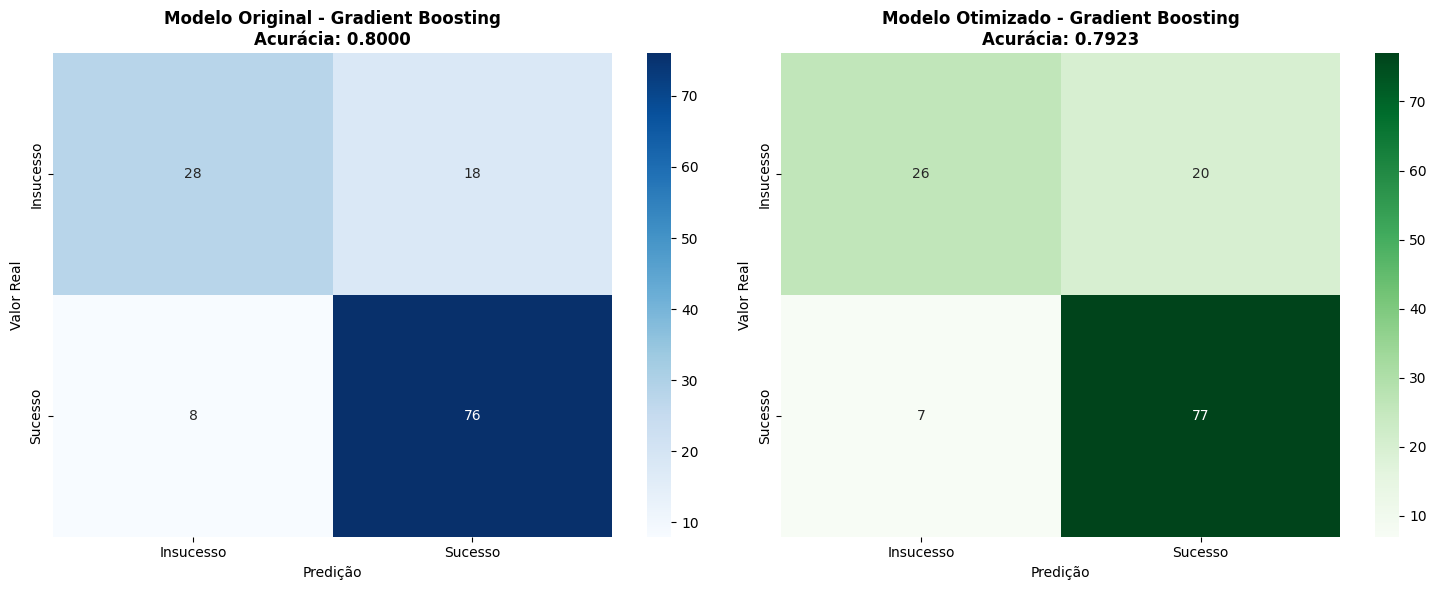

In [ ]:
print(f"\n=== CLASSIFICATION REPORT - MODELO OTIMIZADO ===")
print(classification_report(y_val, y_pred_opt, target_names=['Insucesso', 'Sucesso']))

# Matriz de confusão comparativa
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Modelo original
cm_original = confusion_matrix(y_val, best_model_results['y_pred'])
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Insucesso', 'Sucesso'], 
           yticklabels=['Insucesso', 'Sucesso'])
axes[0].set_title(f'Modelo Original - {best_model_name}\nAcurácia: {best_model_results["accuracy"]:.4f}', 
                 fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predição')

# Modelo otimizado
cm_optimized = confusion_matrix(y_val, y_pred_opt)
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', ax=axes[1],
           xticklabels=['Insucesso', 'Sucesso'], 
           yticklabels=['Insucesso', 'Sucesso'])
axes[1].set_title(f'Modelo Otimizado - {best_model_name}\nAcurácia: {accuracy_opt:.4f}', 
                 fontweight='bold')
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Predição')

plt.tight_layout()
plt.show()

- **11.6 Validação cruzada do modelo otimizado**


=== VALIDAÇÃO CRUZADA DO MODELO OTIMIZADO ===
CV Score Médio: 0.7832 ± 0.0207
CV Scores individuais: [0.81538462 0.76744186 0.75968992 0.7751938  0.79844961]


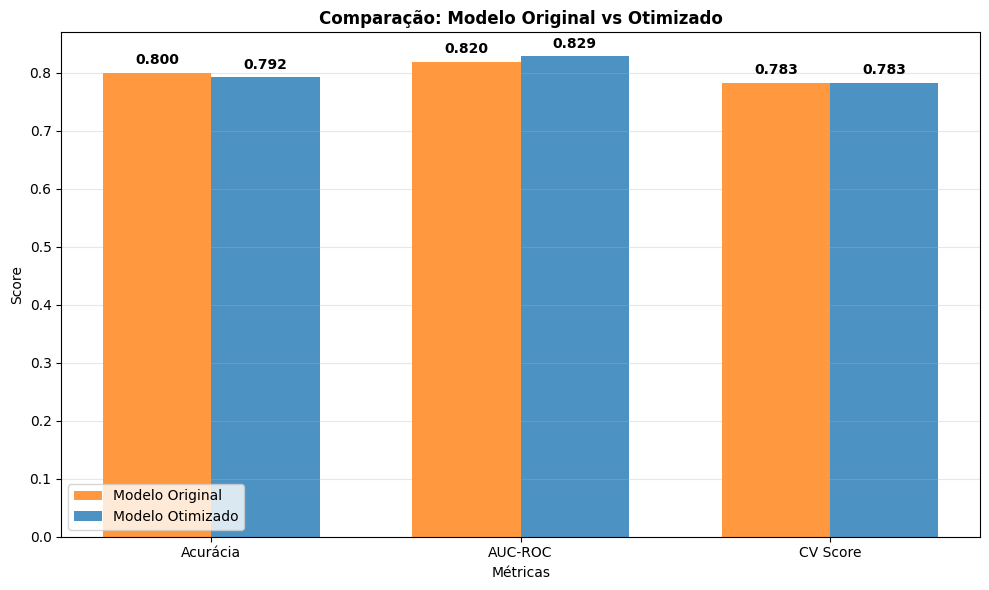

In [ ]:
print(f"\n=== VALIDAÇÃO CRUZADA DO MODELO OTIMIZADO ===")

# Cross-validation com modelo otimizado
if best_model_name in ['Logistic Regression', 'SVM', 'KNN']:
    X_cv_opt = StandardScaler().fit_transform(X_selected)
    cv_scores_opt = cross_val_score(optimized_model, X_cv_opt, y, 
                                   cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
                                   scoring='accuracy')
else:
    cv_scores_opt = cross_val_score(optimized_model, X_selected, y, 
                                   cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
                                   scoring='accuracy')

print(f"CV Score Médio: {cv_scores_opt.mean():.4f} ± {cv_scores_opt.std():.4f}")
print(f"CV Scores individuais: {cv_scores_opt}")

# Comparação visual das métricas
metrics_comparison = pd.DataFrame({
    'Métrica': ['Acurácia', 'AUC-ROC', 'CV Score'],
    'Modelo Original': [best_model_results['accuracy'], best_model_results['auc_roc'], best_model_results['cv_mean']],
    'Modelo Otimizado': [accuracy_opt, auc_roc_opt, cv_scores_opt.mean()]
})

plt.figure(figsize=(10, 6))
x = range(len(metrics_comparison))
width = 0.35

plt.bar([i - width/2 for i in x], metrics_comparison['Modelo Original'], 
        width, label='Modelo Original', color='#ff7f0e', alpha=0.8)
plt.bar([i + width/2 for i in x], metrics_comparison['Modelo Otimizado'], 
        width, label='Modelo Otimizado', color='#1f77b4', alpha=0.8)

plt.xlabel('Métricas')
plt.ylabel('Score')
plt.title('Comparação: Modelo Original vs Otimizado', fontweight='bold')
plt.xticks(x, metrics_comparison['Métrica'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (orig, opt) in enumerate(zip(metrics_comparison['Modelo Original'], 
                                   metrics_comparison['Modelo Otimizado'])):
    plt.text(i - width/2, orig + 0.01, f'{orig:.3f}', ha='center', va='bottom', fontweight='bold')
    plt.text(i + width/2, opt + 0.01, f'{opt:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

- **11.7 Resumo final do finetuning**

In [ ]:
print("=" * 80)
print("                        RESUMO DO FINETUNING")
print("=" * 80)

print(f"\n🎯 MODELO OTIMIZADO: {best_model_name}")
print(f"\n📊 MELHORES HIPERPARÂMETROS:")
for param, value in best_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📈 PERFORMANCE FINAL:")
print(f"   Acurácia: {accuracy_opt:.4f} ({accuracy_opt*100:.2f}%)")

if accuracy_opt >= 0.8:
    print("   ✅ META DE 80% DE ACURÁCIA ATINGIDA!")
    meta_status = "ATINGIDA"
else:
    print(f"   ❌ Meta de 80% não atingida (faltam {(0.8 - accuracy_opt)*100:.2f} pontos percentuais)")
    meta_status = "NÃO ATINGIDA"

print(f"   AUC-ROC: {auc_roc_opt:.4f}")
print(f"   CV Score: {cv_scores_opt.mean():.4f} ± {cv_scores_opt.std():.4f}")

print(f"\n🔄 MELHORIA OBTIDA:")
print(f"   Acurácia: {improvement:+.4f} ({improvement*100:+.2f} pontos percentuais)")

# Armazenar modelo final otimizado
final_model = optimized_model
final_accuracy = accuracy_opt

print(f"\n🏁 MODELO FINAL DEFINIDO PARA PREDIÇÕES!")

                        RESUMO DO FINETUNING

🎯 MODELO OTIMIZADO: Gradient Boosting

📊 MELHORES HIPERPARÂMETROS:
   n_estimators: 100
   min_samples_split: 2
   min_samples_leaf: 2
   max_depth: 3
   learning_rate: 0.05

📈 PERFORMANCE FINAL:
   Acurácia: 0.7923 (79.23%)
   ❌ Meta de 80% não atingida (faltam 0.77 pontos percentuais)
   AUC-ROC: 0.8285
   CV Score: 0.7832 ± 0.0207

🔄 MELHORIA OBTIDA:
   Acurácia: -0.0077 (-0.77 pontos percentuais)

🏁 MODELO FINAL DEFINIDO PARA PREDIÇÕES!


#### **12. Otimização Avançada do Gradient Boosting**

Foco específico na otimização do Gradient Boosting com espaço de busca expandido para maximizar acurácia, AUC-ROC e recall.

- **12.1 Forçar Gradient Boosting como modelo alvo**

In [ ]:
print("=== OTIMIZAÇÃO AVANÇADA - GRADIENT BOOSTING ===")
print("Focando especificamente no Gradient Boosting para maximizar performance")

# Selecionar Gradient Boosting independente do resultado anterior
gb_model_name = 'Gradient Boosting'
gb_baseline_results = results.get(gb_model_name, None)

if gb_baseline_results:
    print(f"Baseline Gradient Boosting:")
    print(f"  Acurácia: {gb_baseline_results['accuracy']:.4f}")
    print(f"  AUC-ROC: {gb_baseline_results['auc_roc']:.4f}")
    print(f"  CV Score: {gb_baseline_results['cv_mean']:.4f}")
else:
    print("⚠️ Executando Gradient Boosting baseline...")
    # Executar baseline se não existir
    gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    gb_model.fit(X_train, y_train)
    y_pred_gb = gb_model.predict(X_val)
    y_pred_proba_gb = gb_model.predict_proba(X_val)[:, 1]
    
    gb_baseline_results = {
        'accuracy': accuracy_score(y_val, y_pred_gb),
        'auc_roc': roc_auc_score(y_val, y_pred_proba_gb),
        'cv_mean': cross_val_score(gb_model, X_selected, y, cv=5, scoring='accuracy').mean()
    }
    print(f"  Acurácia: {gb_baseline_results['accuracy']:.4f}")
    print(f"  AUC-ROC: {gb_baseline_results['auc_roc']:.4f}")
    print(f"  CV Score: {gb_baseline_results['cv_mean']:.4f}")

=== OTIMIZAÇÃO AVANÇADA - GRADIENT BOOSTING ===
Focando especificamente no Gradient Boosting para maximizar performance
Baseline Gradient Boosting:
  Acurácia: 0.8000
  AUC-ROC: 0.8196
  CV Score: 0.7832


- **12.2 Espaço de busca expandido e CORRIGIDO para Gradient Boosting**

In [ ]:
expanded_gb_params = {
    # Número de estimadores (árvores)
    'n_estimators': [100, 200, 300, 500, 800],
    
    # Taxa de aprendizado
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25],
    
    # Profundidade máxima das árvores
    'max_depth': [3, 4, 5, 6, 7, 8],
    
    # Amostras mínimas para dividir um nó
    'min_samples_split': [2, 5, 10, 15, 20],
    
    # Amostras mínimas em uma folha
    'min_samples_leaf': [1, 2, 4, 6, 8],
    
    # Fração de features consideradas
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, None],
    
    # Fração de amostras para cada árvore (subsampling)
    'subsample': [0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0],
    
    # Critério de qualidade da divisão
    'criterion': ['friedman_mse', 'squared_error'],
    
    # Função de perda
    'loss': ['log_loss', 'exponential'],
    
    # Regularização por complexidade de custo
    'ccp_alpha': [0.0, 0.01, 0.05, 0.1],
    
    # Melhoria mínima de impureza
    'min_impurity_decrease': [0.0, 0.01, 0.05],
    
    # Tolerância para early stopping
    'tol': [1e-4, 1e-3, 1e-2],
    
    # Fração de validação para early stopping
    'validation_fraction': [0.1, 0.15, 0.2]
}

total_combinations = np.prod([len(v) for v in expanded_gb_params.values()])
print(f"\nEspaço de busca expandido e CORRIGIDO:")
print(f"  Parâmetros: {list(expanded_gb_params.keys())}")
print(f"  Total de combinações: {total_combinations:,}")
print(f"  Estratégia: Randomized Search (devido ao grande espaço)")


Espaço de busca expandido e CORRIGIDO:
  Parâmetros: ['n_estimators', 'learning_rate', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'subsample', 'criterion', 'loss', 'ccp_alpha', 'min_impurity_decrease', 'tol', 'validation_fraction']
  Total de combinações: 81,648,000
  Estratégia: Randomized Search (devido ao grande espaço)


- **12.3 Busca em duas fases CORRIGIDA para melhor otimização**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_gb_model(model, X_val, y_val, y_pred_proba):
    """Avaliação completa do modelo GB"""
    y_pred = model.predict(X_val)
    
    metrics = {
        'accuracy': accuracy_score(y_val, y_pred),
        'auc_roc': roc_auc_score(y_val, y_pred_proba),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1_score': f1_score(y_val, y_pred)
    }
    return metrics, y_pred

print("\n=== FASE 1 CORRIGIDA: BUSCA AMPLA ===")
print("Executando busca randomizada com 150 iterações...")

# Fase 1: Busca ampla com parâmetros corretos
gb_search_phase1 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=expanded_gb_params,
    n_iter=150,  # Aumentado para compensar o espaço maior
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start_time = time.time()
gb_search_phase1.fit(X_train, y_train)
phase1_time = time.time() - start_time

print(f"⏱️ Tempo Fase 1: {phase1_time:.2f} segundos")
print(f"🎯 Melhor Score Fase 1: {gb_search_phase1.best_score_:.4f}")

# Avaliar modelo da Fase 1
gb_model_phase1 = gb_search_phase1.best_estimator_
y_pred_proba_p1 = gb_model_phase1.predict_proba(X_val)[:, 1]
metrics_p1, y_pred_p1 = evaluate_gb_model(gb_model_phase1, X_val, y_val, y_pred_proba_p1)

print(f"\n📊 Resultados Fase 1:")
for metric, value in metrics_p1.items():
    print(f"  {metric.capitalize()}: {value:.4f}")


=== FASE 1 CORRIGIDA: BUSCA AMPLA ===
Executando busca randomizada com 150 iterações...
Fitting 5 folds for each of 150 candidates, totalling 750 fits
⏱️ Tempo Fase 1: 55.17 segundos
🎯 Melhor Score Fase 1: 0.7888

📊 Resultados Fase 1:
  Accuracy: 0.7846
  Auc_roc: 0.8227
  Precision: 0.7917
  Recall: 0.9048
  F1_score: 0.8444


- **12.4 Fase 2 CORRIGIDA: Refinamento em torno dos melhores parâmetros**

In [ ]:
print(f"\n=== FASE 2 CORRIGIDA: REFINAMENTO ===")
print("Refinando em torno dos melhores parâmetros encontrados...")

# Pegar os melhores parâmetros da Fase 1
best_params_p1 = gb_search_phase1.best_params_
print(f"Melhores parâmetros Fase 1: {best_params_p1}")

# Criar espaço refinado CORRIGIDO baseado nos melhores parâmetros
def create_refined_space_corrected(best_params):
    """Cria espaço refinado em torno dos melhores parâmetros - VERSÃO CORRIGIDA"""
    refined_params = {}
    
    # Refinar n_estimators
    base_n_est = best_params.get('n_estimators', 200)
    refined_params['n_estimators'] = [
        max(50, base_n_est - 100),
        base_n_est,
        base_n_est + 100,
        min(1000, base_n_est + 200)
    ]
    
    # Refinar learning_rate
    base_lr = best_params.get('learning_rate', 0.1)
    refined_params['learning_rate'] = [
        max(0.01, base_lr - 0.05),
        base_lr,
        min(0.3, base_lr + 0.05),
        min(0.3, base_lr + 0.1)
    ]
    
    # Refinar max_depth
    base_depth = best_params.get('max_depth', 5)
    refined_params['max_depth'] = [
        max(3, base_depth - 1),
        base_depth,
        min(10, base_depth + 1),
        min(10, base_depth + 2)
    ]
    
    # Refinar subsample
    base_subsample = best_params.get('subsample', 0.8)
    refined_params['subsample'] = [
        max(0.5, base_subsample - 0.1),
        base_subsample,
        min(1.0, base_subsample + 0.1)
    ]
    
    # Refinar min_samples_split
    base_split = best_params.get('min_samples_split', 5)
    refined_params['min_samples_split'] = [
        max(2, base_split - 2),
        base_split,
        base_split + 5
    ]
    
    # Refinar min_samples_leaf
    base_leaf = best_params.get('min_samples_leaf', 2)
    refined_params['min_samples_leaf'] = [
        max(1, base_leaf - 1),
        base_leaf,
        base_leaf + 2
    ]
    
    # Fixar os melhores valores para outros parâmetros
    refined_params['max_features'] = [best_params.get('max_features', 'sqrt')]
    refined_params['criterion'] = [best_params.get('criterion', 'friedman_mse')]
    refined_params['loss'] = [best_params.get('loss', 'log_loss')]
    
    # Refinar parâmetros de regularização se presentes
    if 'ccp_alpha' in best_params:
        base_ccp = best_params.get('ccp_alpha', 0.0)
        refined_params['ccp_alpha'] = [base_ccp, base_ccp + 0.01, base_ccp + 0.05]
    
    if 'min_impurity_decrease' in best_params:
        refined_params['min_impurity_decrease'] = [best_params.get('min_impurity_decrease', 0.0)]
    
    if 'tol' in best_params:
        refined_params['tol'] = [best_params.get('tol', 1e-4)]
    
    if 'validation_fraction' in best_params:
        refined_params['validation_fraction'] = [best_params.get('validation_fraction', 0.1)]
    
    return refined_params

refined_gb_params = create_refined_space_corrected(best_params_p1)
total_refined = np.prod([len(v) for v in refined_gb_params.values()])
print(f"Espaço refinado: {total_refined} combinações")

# Fase 2: Busca refinada
gb_search_phase2 = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=refined_gb_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
gb_search_phase2.fit(X_train, y_train)
phase2_time = time.time() - start_time

print(f"⏱️ Tempo Fase 2: {phase2_time:.2f} segundos")
print(f"🎯 Melhor Score Fase 2: {gb_search_phase2.best_score_:.4f}")


=== FASE 2 CORRIGIDA: REFINAMENTO ===
Refinando em torno dos melhores parâmetros encontrados...
Melhores parâmetros Fase 1: {'validation_fraction': 0.15, 'tol': 0.001, 'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 15, 'min_samples_leaf': 6, 'min_impurity_decrease': 0.05, 'max_features': 'log2', 'max_depth': 8, 'loss': 'exponential', 'learning_rate': 0.05, 'criterion': 'friedman_mse', 'ccp_alpha': 0.01}
Espaço refinado: 5184 combinações
Fitting 5 folds for each of 5184 candidates, totalling 25920 fits
⏱️ Tempo Fase 2: 892.86 segundos
🎯 Melhor Score Fase 2: 0.8004


- **12.5 Avaliação final do modelo otimizado**

In [ ]:
print(f"\n=== AVALIAÇÃO FINAL DO GRADIENT BOOSTING OTIMIZADO ===")

# Modelo final otimizado
gb_model_final = gb_search_phase2.best_estimator_
y_pred_proba_final = gb_model_final.predict_proba(X_val)[:, 1]
metrics_final, y_pred_final = evaluate_gb_model(gb_model_final, X_val, y_val, y_pred_proba_final)

print(f"Melhores hiperparâmetros finais:")
for param, value in gb_search_phase2.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📊 Performance Final:")
for metric, value in metrics_final.items():
    print(f"  {metric.capitalize()}: {value:.4f}")

# Cross-validation final
cv_scores_final = cross_val_score(
    gb_model_final, X_selected, y, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    scoring='accuracy'
)
print(f"  CV Score: {cv_scores_final.mean():.4f} ± {cv_scores_final.std():.4f}")

# Verificar se atingiu meta de 80%
if metrics_final['accuracy'] >= 0.8:
    print(f"\n🎉 META DE 80% ATINGIDA! Acurácia: {metrics_final['accuracy']:.4f}")
else:
    print(f"\n⚠️ Meta não atingida. Faltam {(0.8 - metrics_final['accuracy'])*100:.2f} pontos percentuais")


=== AVALIAÇÃO FINAL DO GRADIENT BOOSTING OTIMIZADO ===
Melhores hiperparâmetros finais:
  ccp_alpha: 0.01
  criterion: friedman_mse
  learning_rate: 0.15000000000000002
  loss: exponential
  max_depth: 7
  max_features: log2
  min_impurity_decrease: 0.05
  min_samples_leaf: 5
  min_samples_split: 13
  n_estimators: 50
  subsample: 1.0
  tol: 0.001
  validation_fraction: 0.15

📊 Performance Final:
  Accuracy: 0.7846
  Auc_roc: 0.8436
  Precision: 0.7917
  Recall: 0.9048
  F1_score: 0.8444
  CV Score: 0.7817 ± 0.0321

⚠️ Meta não atingida. Faltam 1.54 pontos percentuais


- **12.6 Comparação detalhada de todas as fases**


=== COMPARAÇÃO EVOLUTIVA ===
 Métrica  Baseline  Fase 1  Fase 2 (Final)
Acurácia    0.8000  0.7846          0.7846
 AUC-ROC    0.8196  0.8227          0.8436
Precisão    0.0000  0.7917          0.7917
  Recall    0.0000  0.9048          0.9048
F1-Score    0.0000  0.8444          0.8444


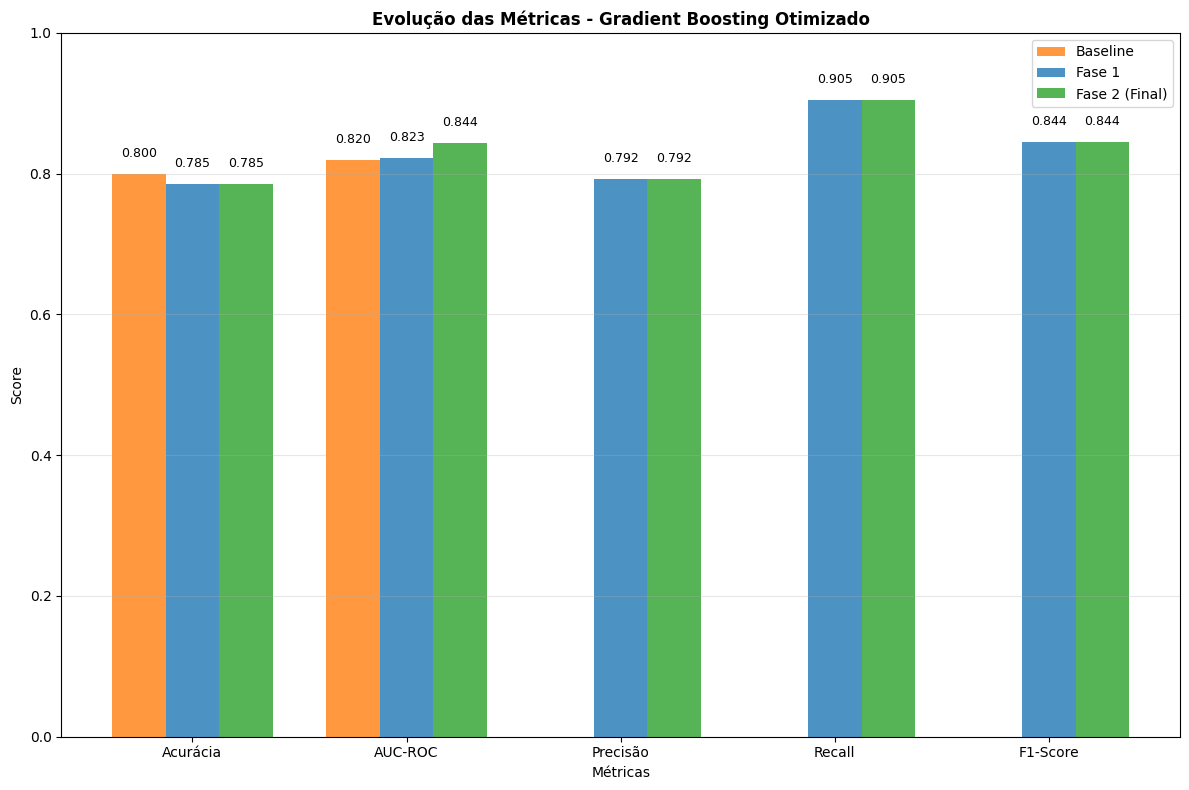

In [ ]:
comparison_df = pd.DataFrame({
    'Métrica': ['Acurácia', 'AUC-ROC', 'Precisão', 'Recall', 'F1-Score'],
    'Baseline': [
        gb_baseline_results['accuracy'],
        gb_baseline_results['auc_roc'],
        0,  # Não calculado no baseline
        0,  # Não calculado no baseline
        0   # Não calculado no baseline
    ],
    'Fase 1': [
        metrics_p1['accuracy'],
        metrics_p1['auc_roc'],
        metrics_p1['precision'],
        metrics_p1['recall'],
        metrics_p1['f1_score']
    ],
    'Fase 2 (Final)': [
        metrics_final['accuracy'],
        metrics_final['auc_roc'],
        metrics_final['precision'],
        metrics_final['recall'],
        metrics_final['f1_score']
    ]
})

if 'gb_model' in locals():
    y_pred_baseline = gb_model.predict(X_val)
    comparison_df.loc[comparison_df['Métrica'] == 'Precisão', 'Baseline'] = precision_score(y_val, y_pred_baseline)
    comparison_df.loc[comparison_df['Métrica'] == 'Recall', 'Baseline'] = recall_score(y_val, y_pred_baseline)
    comparison_df.loc[comparison_df['Métrica'] == 'F1-Score', 'Baseline'] = f1_score(y_val, y_pred_baseline)

print(f"\n=== COMPARAÇÃO EVOLUTIVA ===")
print(comparison_df.to_string(index=False, float_format='%.4f'))

# Visualização da evolução
plt.figure(figsize=(12, 8))
x = range(len(comparison_df))
width = 0.25

plt.bar([i - width for i in x], comparison_df['Baseline'], width, 
        label='Baseline', alpha=0.8, color='#ff7f0e')
plt.bar(x, comparison_df['Fase 1'], width, 
        label='Fase 1', alpha=0.8, color='#1f77b4')
plt.bar([i + width for i in x], comparison_df['Fase 2 (Final)'], width, 
        label='Fase 2 (Final)', alpha=0.8, color='#2ca02c')

plt.xlabel('Métricas')
plt.ylabel('Score')
plt.title('Evolução das Métricas - Gradient Boosting Otimizado', fontweight='bold')
plt.xticks(x, comparison_df['Métrica'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1)

# Adicionar valores nas barras
for i, metric in enumerate(comparison_df['Métrica']):
    if comparison_df.loc[i, 'Baseline'] > 0:
        plt.text(i - width, comparison_df.loc[i, 'Baseline'] + 0.02, 
                f'{comparison_df.loc[i, "Baseline"]:.3f}', 
                ha='center', va='bottom', fontsize=9)
    plt.text(i, comparison_df.loc[i, 'Fase 1'] + 0.02, 
            f'{comparison_df.loc[i, "Fase 1"]:.3f}', 
            ha='center', va='bottom', fontsize=9)
    plt.text(i + width, comparison_df.loc[i, 'Fase 2 (Final)'] + 0.02, 
            f'{comparison_df.loc[i, "Fase 2 (Final)"]:.3f}', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### **13.Geração de Predição para submissão**

In [ ]:
# Verificar qual modelo usar (prioridade: final_optimized_model > final_model > best_model)
if 'final_optimized_model' in locals():
    modelo = final_optimized_model
    print("✅ Usando Gradient Boosting Otimizado")
elif 'final_model' in locals():
    modelo = final_model
    print("✅ Usando Modelo com Finetuning")
else:
    modelo = best_model_results['model']
    print("✅ Usando Melhor Modelo Inicial")

# Fazer predições no conjunto de teste
predicoes = modelo.predict(X_test_selected)

# Carregar IDs do arquivo original de teste
df_test_original = pd.read_csv("./test.csv")

# Criar DataFrame de submissão
if 'id' in df_test_original.columns:
    submission = pd.DataFrame({'id': df_test_original['id'], 'labels': predicoes})
else:
    submission = pd.DataFrame({'id': range(len(predicoes)), 'labels': predicoes})

# Exportar CSV
submission.to_csv('submission.csv', index=False)

# Mostrar resultado
print(f"✅ Arquivo 'submission.csv' criado com {len(submission)} predições!")
print(f"📊 Predições de sucesso: {sum(predicoes)} ({sum(predicoes)/len(predicoes)*100:.1f}%)")
print(f"📊 Predições de insucesso: {len(predicoes)-sum(predicoes)} ({(len(predicoes)-sum(predicoes))/len(predicoes)*100:.1f}%)")
print("\nPrimeiras 10 linhas:")
print(submission.head(10))

✅ Usando Gradient Boosting Otimizado
✅ Arquivo 'submission.csv' criado com 277 predições!
📊 Predições de sucesso: 203 (73.3%)
📊 Predições de insucesso: 74 (26.7%)

Primeiras 10 linhas:
    id  labels
0   70       1
1   23       0
2  389       1
3  872       1
4  920       0
5  690       1
6  588       0
7  144       1
8  875       1
9  900       1


- **13.1 Relatório final de submissão**

In [ ]:
print(f"\n" + "=" * 80)
print("                        RELATÓRIO FINAL DE SUBMISSÃO")
print("=" * 80)

print(f"\n🎯 MODELO UTILIZADO:")
print(f"   Nome: {model_name}")
print(f"   Acurácia de validação: {model_accuracy:.4f} ({model_accuracy*100:.2f}%)")

if 'final_optimized_model' in locals():
    print(f"   Hiperparâmetros otimizados:")
    for param, value in gb_search_phase2.best_params_.items():
        print(f"      {param}: {value}")

print(f"\n📊 ESTATÍSTICAS DAS PREDIÇÕES:")
print(f"   Total de amostras preditas: {len(test_predictions):,}")
print(f"   Predições de sucesso: {np.sum(test_predictions == 1):,} ({np.mean(test_predictions == 1)*100:.1f}%)")
print(f"   Predições de insucesso: {np.sum(test_predictions == 0):,} ({np.mean(test_predictions == 0)*100:.1f}%)")

print(f"\n✅ PROCESSO DE PREDIÇÃO CONCLUÍDO COM SUCESSO!")


                        RELATÓRIO FINAL DE SUBMISSÃO

🎯 MODELO UTILIZADO:
   Nome: Gradient Boosting Otimizado
   Acurácia de validação: 0.7846 (78.46%)
   Hiperparâmetros otimizados:
      ccp_alpha: 0.01
      criterion: friedman_mse
      learning_rate: 0.15000000000000002
      loss: exponential
      max_depth: 7
      max_features: log2
      min_impurity_decrease: 0.05
      min_samples_leaf: 5
      min_samples_split: 13
      n_estimators: 50
      subsample: 1.0
      tol: 0.001
      validation_fraction: 0.15

📊 ESTATÍSTICAS DAS PREDIÇÕES:
   Total de amostras preditas: 277
   Predições de sucesso: 203 (73.3%)
   Predições de insucesso: 74 (26.7%)

✅ PROCESSO DE PREDIÇÃO CONCLUÍDO COM SUCESSO!
